In [1]:

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

In [2]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2021].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2021,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.9033, alpha=0.0000, beta=0.9138


In [3]:
df_2022 = df[df['Year'] == 2022].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2022)} daily SoRad prices for 2022...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2022.iterrows()])
R_arr  = df_2022['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2022...


27.13177687698869

In [6]:
# =============================================================================
# Monte Carlo Simulation for Barrier Option Pricing
# =============================================================================

from solarrpy.forecastDensity import clearsky_at, seasonal_mean_Y_at, R_to_Y, Y_to_R
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# -----------------------------------------------------------------------------
# 1. Precompute daily values for the target year
# -----------------------------------------------------------------------------
year = 2022
n_days = 365 + (1 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 0)
dates = pd.date_range(f'{year}-01-01', periods=n_days, freq='D')

# Deterministic series using package functions
C_t = np.array([clearsky_at(d, cal) for d in dates])
Ybar_t = np.array([seasonal_mean_Y_at(d, cal) for d in dates])

omega = 2 * np.pi / 365
t_days = np.arange(1, n_days + 1)
sigma_bar_t = np.sqrt(cal.c[0] + cal.c[1] * np.sin(omega * t_days) + cal.c[2] * np.cos(omega * t_days))

# Monthly mixture parameters
monthly_df = cal.monthly_mixture.set_index('Month')
p_month = monthly_df['p'].values
mu0_month = monthly_df['mu0'].values
mu1_month = monthly_df['mu1'].values
sigma0_month = monthly_df['sd0'].values
sigma1_month = monthly_df['sd1'].values

# Initial Y on day before year start
prev_date = pd.Timestamp(f'{year-1}-12-31')
prev_R = df[df['date'] == prev_date]['GHI'].values[0]
C_prev = clearsky_at(prev_date, cal)
Y_prev = R_to_Y(prev_R, C_prev, cal.alpha, cal.beta)

# -----------------------------------------------------------------------------
# 2. Precompute I and J integrals for each day
# -----------------------------------------------------------------------------
int_I = integral_sigma_numeric(cal.theta, cal.c)
int_J = integral_sigma2_formula(cal.theta, cal.gamma)
ns = dates.dayofyear.values.astype(float)
I_daily = int_I(ns - 1, ns, ns).ravel()
J_daily = int_J(ns - 1, ns, ns).ravel()

# -----------------------------------------------------------------------------
# 3. Exact Monte Carlo simulation
# -----------------------------------------------------------------------------
np.random.seed(12345)
n_sim = 50000   # Number of simulation paths
print(f"Simulating {n_sim} paths for {year} using exact daily transition...")

all_R = np.zeros((n_sim, n_days))
for sim in range(n_sim):
    if sim % 10000 == 0:
        print(f"  Path {sim}/{n_sim}")
    Y = np.zeros(n_days)
    Y_curr = Y_prev
    for i in range(n_days):
        month_idx = dates[i].month - 1
        B = np.random.binomial(1, p_month[month_idx])          # 1 = cloudy
        mu_B = mu1_month[month_idx] if B else mu0_month[month_idx]
        sigma_B = sigma1_month[month_idx] if B else sigma0_month[month_idx]
        if i == 0:
            prev_day = dates[0] - pd.Timedelta(days=1)
            Ybar_curr = seasonal_mean_Y_at(prev_day, cal)
        else:
            Ybar_curr = Ybar_t[i-1]
        Ybar_next = Ybar_t[i]
        Y_next = (Ybar_next
                  + (Y_curr - Ybar_curr) * np.exp(-cal.theta)
                  + mu_B * I_daily[i]
                  + sigma_B * np.sqrt(J_daily[i]) * np.random.normal())
        Y[i] = Y_next
        Y_curr = Y_next
    all_R[sim] = np.array([Y_to_R(y, C_t[i], cal.alpha, cal.beta) for i, y in enumerate(Y)])
print("Simulation done.")

# Extract actual GHI for the year
R_actual = df_2022['GHI'].values
K_daily = K_arr  # from previous cell
cf_bench = cf_b
cf_u = cf_u

print(f"Simulation complete: {all_R.shape[0]} paths x {all_R.shape[1]} days")

Simulating 50000 paths for 2022 using exact daily transition...
  Path 0/50000
  Path 10000/50000
  Path 20000/50000
  Path 30000/50000
  Path 40000/50000
Simulation done.
Simulation complete: 50000 paths x 365 days


In [7]:
# =============================================================================
# BARRIER OPTIONS WITH SEASONAL MEAN BARRIER
# Two types: Down-and-In (R < K_t) and Up-and-In (R > K_t)
# =============================================================================

def price_barrier_option(all_R, R_actual, K_daily, barrier_type='down_and_in', 
                          tick=tick, n_days=n_days, n_sim=n_sim, cf_u=cf_u, cf_bench=cf_bench):
    """
    Price barrier option with barrier = seasonal mean (K_t)
    
    Parameters:
    - barrier_type: 'down_and_in' (knocks in when R < K_t) or 'up_and_in' (knocks in when R > K_t)
    """
    
    # Determine knock-in condition
    if barrier_type == 'down_and_in':
        knock_condition = lambda series, K: series < K
        condition_name = "Down-and-In (R < K_t)"
    elif barrier_type == 'up_and_in':
        knock_condition = lambda series, K: series > K
        condition_name = "Up-and-In (R > K_t)"
    else:
        raise ValueError("barrier_type must be 'down_and_in' or 'up_and_in'")
    
    print(f"\n{'='*60}")
    print(f"Pricing {condition_name}")
    print(f"{'='*60}")
    
    # -------------------------------------------------------------------------
    # Find knock-in day for each simulated path
    # -------------------------------------------------------------------------
    knock_days = np.full(n_sim, n_days, dtype=int)
    
    for sim in range(n_sim):
        for i in range(n_days):
            if knock_condition(all_R[sim, i], K_daily[i]):
                knock_days[sim] = i
                break
    
    knock_rate = 100 * np.mean(knock_days < n_days)
    print(f"  Knock-in rate (simulated): {knock_rate:.1f}%")
    
    # -------------------------------------------------------------------------
    # Calculate premium V0 for each day
    # -------------------------------------------------------------------------
    V0 = np.zeros(n_days)
    for T in range(n_days):
        indicator = (knock_days <= T).astype(float)
        payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
        V0[T] = np.mean(payoff_T * indicator)
    
    # -------------------------------------------------------------------------
    # Find actual knock-in day (historical)
    # -------------------------------------------------------------------------
    actual_knock_day = n_days
    for i in range(n_days):
        if knock_condition(R_actual[i], K_daily[i]):
            actual_knock_day = i
            break
    
    ki_str = f"day {actual_knock_day+1}" if actual_knock_day < n_days else "NEVER"
    print(f"  Actual knock-in: {ki_str}")
    
    # -------------------------------------------------------------------------
    # Calculate actual payoff
    # -------------------------------------------------------------------------
    actual_payoff = np.zeros(n_days)
    if actual_knock_day < n_days:
        for T in range(actual_knock_day, n_days):
            actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
    
    # -------------------------------------------------------------------------
    # Calculate delta and optimal Nc
    # -------------------------------------------------------------------------
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    if denom > 1e-12:
        Nc = -np.sum((cf_u - cf_bench) * delta) / denom
        Nc = max(Nc, 0)  # No short selling
    else:
        Nc = 0
    
    print(f"  Optimal Nc: {Nc:.1f}")
    
    # -------------------------------------------------------------------------
    # Calculate hedged cash flows
    # -------------------------------------------------------------------------
    cf_hedged = cf_u + Nc * delta
    mape_u_val = mape(cf_u, cf_bench)
    mape_h_val = mape(cf_hedged, cf_bench)
    
    print(f"  MAPE: {mape_u_val:.2f}% → {mape_h_val:.2f}%")
    
    # Performance metrics
    var_u = np.var(cf_u - cf_bench)
    var_h = np.var(cf_hedged - cf_bench)
    var_reduction = 100 * (1 - var_h / var_u) if var_u > 0 else 0
    print(f"  Variance reduction: {var_reduction:.1f}%")
    
    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------
    results = {
        'type': barrier_type,
        'condition_name': condition_name,
        'V0': V0,
        'delta': delta,
        'Nc': Nc,
        'cf_hedged': cf_hedged,
        'mape_u': mape_u_val,
        'mape_h': mape_h_val,
        'var_reduction': var_reduction,
        'knock_rate': knock_rate,
        'actual_knock_day': actual_knock_day,
        'actual_payoff': actual_payoff,
        'cf_u': cf_u,
        'cf_bench': cf_bench,
        'K_daily': K_daily,
        'R_actual': R_actual,
        'knock_days_sim': knock_days
    }
    
    return results

# Price both barrier types
results_dni = price_barrier_option(all_R, R_actual, K_daily, barrier_type='down_and_in')
results_upi = price_barrier_option(all_R, R_actual, K_daily, barrier_type='up_and_in')


Pricing Down-and-In (R < K_t)
  Knock-in rate (simulated): 100.0%
  Actual knock-in: day 3
  Optimal Nc: 1500.1
  MAPE: 27.13% → 11.31%
  Variance reduction: 87.9%

Pricing Up-and-In (R > K_t)
  Knock-in rate (simulated): 100.0%
  Actual knock-in: day 1
  Optimal Nc: 1500.0
  MAPE: 27.13% → 11.35%
  Variance reduction: 87.8%



GENERATING FIGURE 4 STYLE PLOTS FOR BARRIER OPTIONS

--------------------------------------------------
Down-and-In Barrier (R < K_t)
--------------------------------------------------


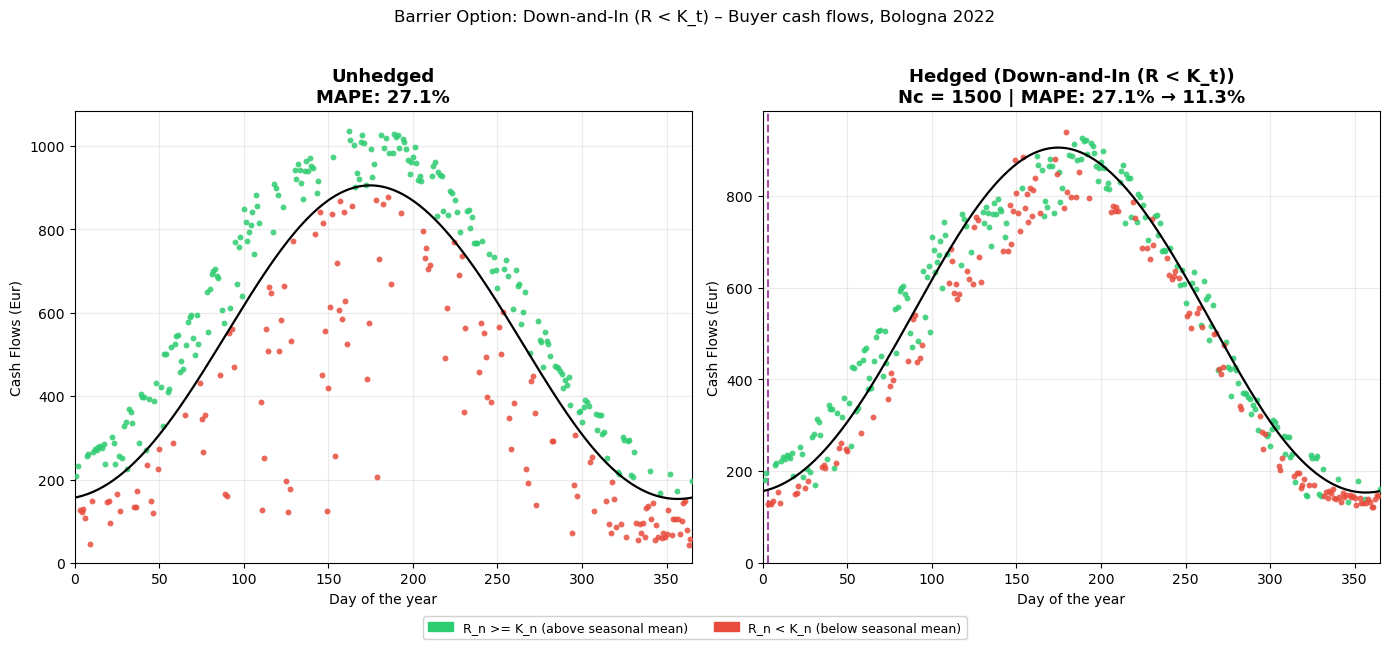

Plot saved: ../results/Figure_Barrier_2022_down_and_in.png

--------------------------------------------------
Up-and-In Barrier (R > K_t)
--------------------------------------------------


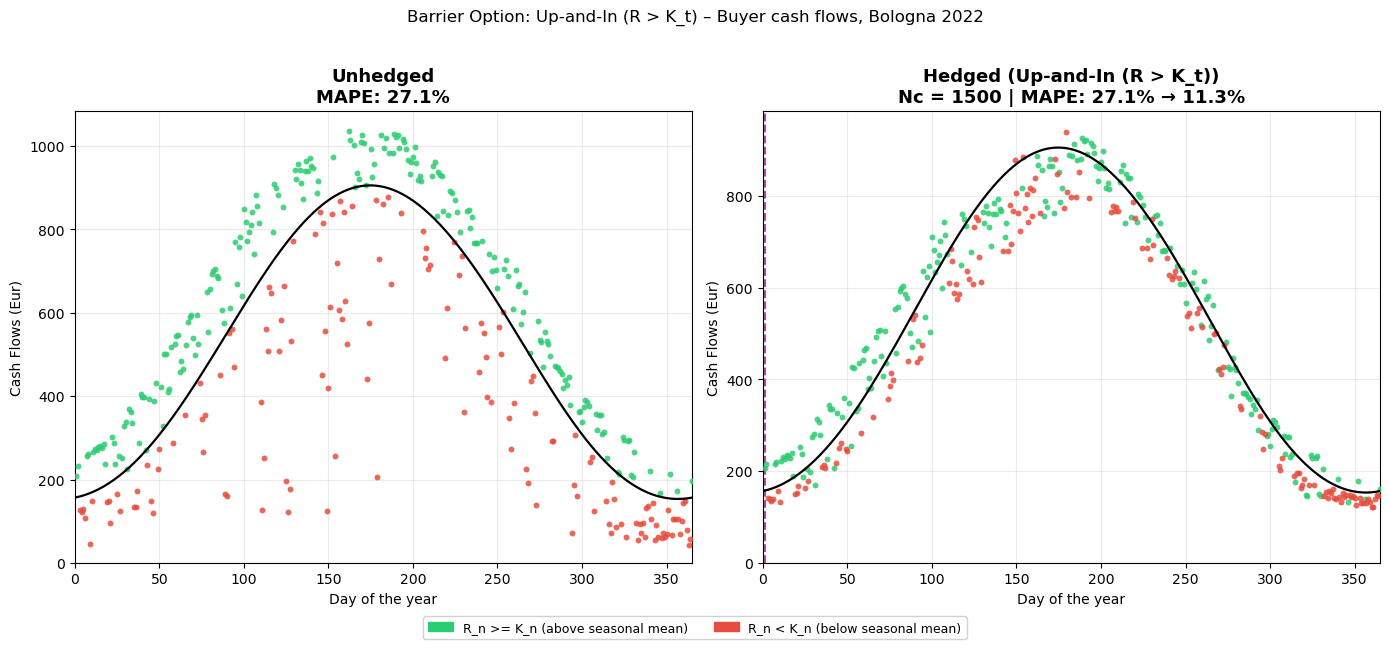

Plot saved: ../results/Figure_Barrier_2022_up_and_in.png


In [15]:
# =============================================================================
# FIGURE 4 STYLE: Barrier Option Buyer Cash Flows
# Down-and-In and Up-and-In with Seasonal Mean Barrier
# =============================================================================

def plot_barrier_figure4(results, title_suffix="", save_suffix=""):
    """Create Figure 4 style plots for barrier options"""
    
    # Get data
    cf_u = results['cf_u']
    cf_h = results['cf_hedged']
    cf_bench = results['cf_bench']
    R_actual = results['R_actual']
    K_daily = results['K_daily']
    Nc = results['Nc']
    mape_u = results['mape_u']
    mape_h = results['mape_h']
    actual_knock_day = results['actual_knock_day']
    
    # Determine colors based on whether R >= K (above seasonal mean)
    above = R_actual >= K_daily
    
    # Create dense benchmark curve for smooth line
    dates_dense = pd.date_range('2022-01-01', '2022-12-31', freq='D')
    # For dense K, we need to recompute strikes for each day
    K_dense = np.array([daily_strike(d, cal) for d in dates_dense])
    cfb_dense = benchmark_cf(K_dense)
    days_dense = np.arange(1, len(dates_dense) + 1)
    
    # Day indices
    days_idx = np.arange(1, len(cf_u) + 1)
    
    # Create legend patches
    legend_patches = [
        mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
        mpatches.Patch(color='#e74c3c', label='R_n < K_n (below seasonal mean)'),
    ]
    
    # Create figure with 2 subplots (Unhedged and Hedged)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ========================================================================
    # LEFT PLOT: Unhedged
    # ========================================================================
    ax1 = axes[0]
    
    # Scatter points with colors
    ax1.scatter(days_idx[above], cf_u[above], s=18, color='#2ecc71', 
                alpha=0.85, zorder=3, linewidths=0, label='R_n >= K_n')
    ax1.scatter(days_idx[~above], cf_u[~above], s=18, color='#e74c3c', 
                alpha=0.85, zorder=3, linewidths=0, label='R_n < K_n')
    
    # Seasonal benchmark line
    ax1.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4, label='Seasonal Benchmark')
    
    # Add horizontal line at 0
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax1.set_title(f'Unhedged\nMAPE: {mape_u:.1f}%', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Day of the year', fontsize=10)
    ax1.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax1.set_xlim(0, 365)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.25)
    
    # ========================================================================
    # RIGHT PLOT: Hedged
    # ========================================================================
    ax2 = axes[1]
    
    # Scatter points with colors
    ax2.scatter(days_idx[above], cf_h[above], s=18, color='#2ecc71', 
                alpha=0.85, zorder=3, linewidths=0)
    ax2.scatter(days_idx[~above], cf_h[~above], s=18, color='#e74c3c', 
                alpha=0.85, zorder=3, linewidths=0)
    
    # Seasonal benchmark line
    ax2.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4, label='Seasonal Benchmark')
    
    # Add knock-in vertical line if applicable
    if actual_knock_day < len(cf_u):
        ax2.axvline(x=actual_knock_day + 1, color='purple', linestyle='--', 
                    linewidth=1.5, alpha=0.7, label=f'Knock-in day {actual_knock_day + 1}')
    
    # Add horizontal line at 0
    ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax2.set_title(f'Hedged ({results["condition_name"]})\nNc = {Nc:.0f} | MAPE: {mape_u:.1f}% → {mape_h:.1f}%', 
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel('Day of the year', fontsize=10)
    ax2.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax2.set_xlim(0, 365)
    ax2.set_ylim(bottom=0)
    ax2.grid(True, alpha=0.25)
    
    # Add legend to the figure (shared)
    fig.legend(handles=legend_patches, loc='lower center', ncol=2,
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
    
    # Main title
    fig.suptitle(f'Barrier Option: {results["condition_name"]} – Buyer cash flows, Bologna 2022',
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    
    # Save the figure
    save_name = f'../results/Figure_Barrier_{save_suffix}_{results["type"]}.png' if save_suffix else f'../results/Figure_Barrier_{results["type"]}.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: {save_name}")
    
    return fig


# =============================================================================
# Generate Figure 4 style plots for both barrier types
# =============================================================================

print("\n" + "="*70)
print("GENERATING FIGURE 4 STYLE PLOTS FOR BARRIER OPTIONS")
print("="*70)

# Plot Down-and-In Barrier
if 'results_dni' in locals():
    print("\n" + "-"*50)
    print("Down-and-In Barrier (R < K_t)")
    print("-"*50)
    plot_barrier_figure4(results_dni, save_suffix="2022")
else:
    print("results_dni not found. Please run the barrier pricing cell first.")

# Plot Up-and-In Barrier
if 'results_upi' in locals():
    print("\n" + "-"*50)
    print("Up-and-In Barrier (R > K_t)")
    print("-"*50)
    plot_barrier_figure4(results_upi, save_suffix="2022")
else:
    print("results_upi not found. Please run the barrier pricing cell first.")


# =============================================================================
# BONUS: Combined Figure with all three barrier types side by side
# =============================================================================

def plot_all_barriers_comparison(results_dni, results_upi, results_max_below=None):
    """Create a comparison figure with all barrier types"""
    
    # Collect results
    barrier_results = [
        (results_dni, "Down-and-In\n(R < K_t)", "#2ecc71"),
        (results_upi, "Up-and-In\n(R > K_t)", "#e74c3c"),
    ]
    
    if results_max_below is not None:
        barrier_results.append((results_max_below, f"Max < K_t\n({results_max_below['window_desc']})", "#3498db"))
    
    n_plots = len(barrier_results)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    days_idx = np.arange(1, len(results_dni['cf_u']) + 1)
    above = results_dni['R_actual'] >= results_dni['K_daily']
    
    for i, (results, title, color) in enumerate(barrier_results):
        ax = axes[i]
        
        # Hedged cash flows
        ax.scatter(days_idx[above], results['cf_hedged'][above], s=15, 
                   color='#2ecc71', alpha=0.7, zorder=3)
        ax.scatter(days_idx[~above], results['cf_hedged'][~above], s=15, 
                   color='#e74c3c', alpha=0.7, zorder=3)
        
        # Benchmark line
        ax.plot(days_idx, results['cf_bench'], 'k-', lw=1.5, zorder=4)
        
        # Knock-in line
        if results['actual_knock_day'] < len(days_idx):
            ax.axvline(x=results['actual_knock_day'] + 1, color='purple', 
                       linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_title(f'{title}\nNc={results["Nc"]:.0f} | MAPE: {results["mape_u"]:.1f}% → {results["mape_h"]:.1f}%', 
                     fontsize=10)
        ax.set_xlabel('Day of the year', fontsize=9)
        if i == 0:
            ax.set_ylabel('Cash Flows (Eur)', fontsize=9)
        ax.set_xlim(0, 365)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.25)
    
    plt.tight_layout()
    plt.savefig('../results/Figure_Barrier_AllTypes_Comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: ../results/Figure_Barrier_AllTypes_Comparison.png")

# Uncomment to run the comparison plot
# if 'results_dni' in locals() and 'results_upi' in locals():
#     plot_all_barriers_comparison(results_dni, results_upi)

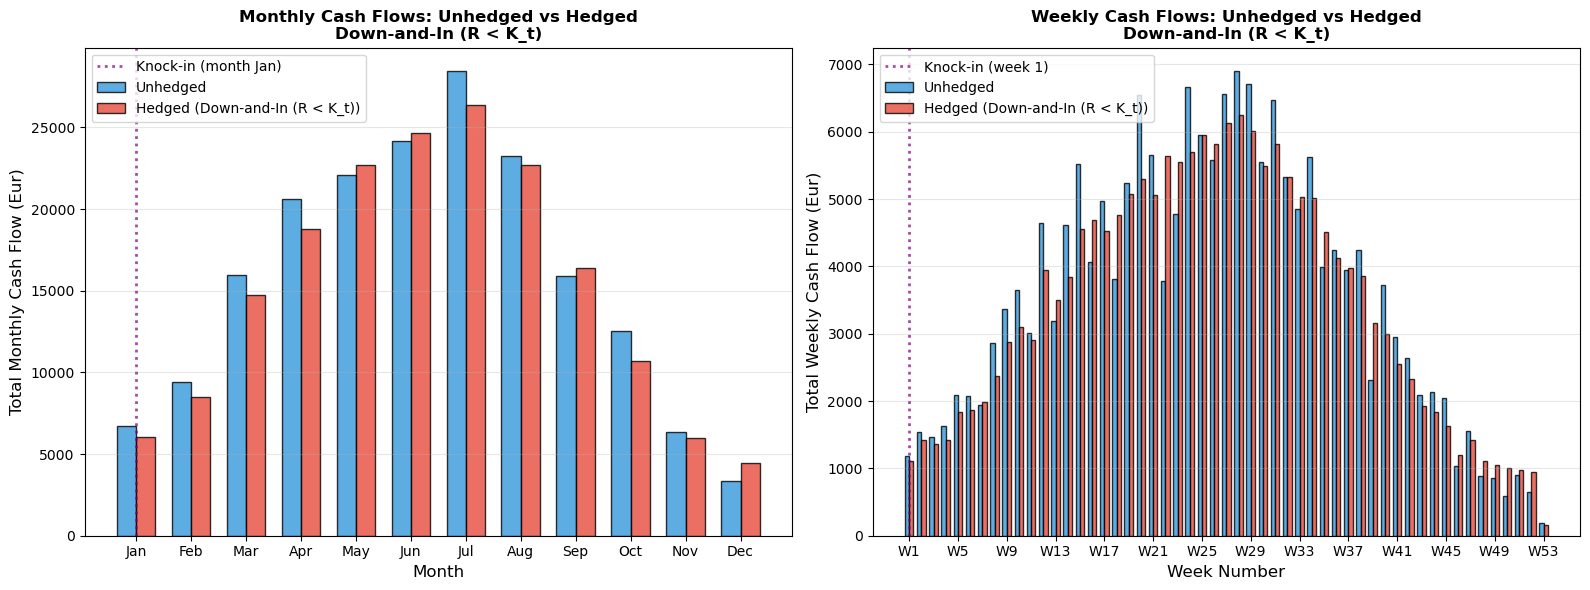

Plot saved: ../results/Barrier_down_and_in_Monthly_Weekly_Comparison.png


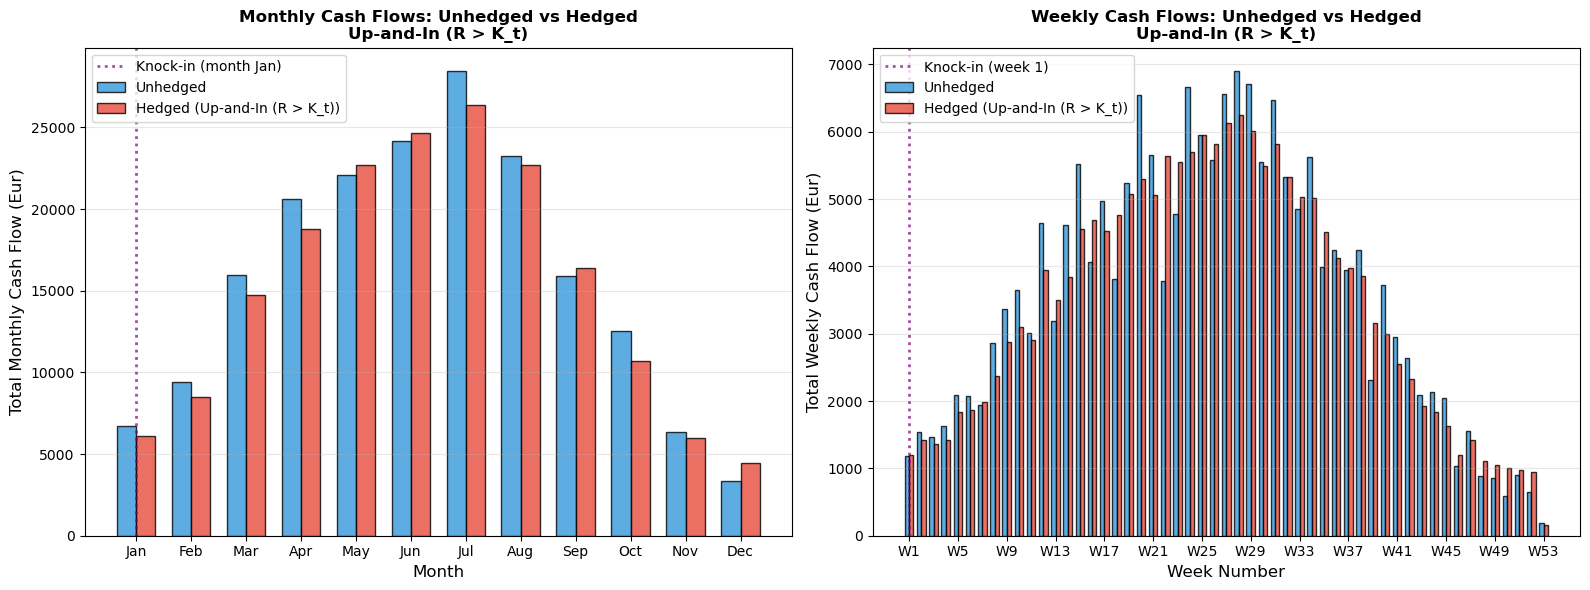

Plot saved: ../results/Barrier_up_and_in_Monthly_Weekly_Comparison.png


In [8]:
# =============================================================================
# Monthly and Weekly Cash Flow Comparison
# =============================================================================

def plot_monthly_weekly_comparison(results):
    """Create monthly and weekly bar charts comparing hedged vs unhedged"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # =========================================================================
    # LEFT PLOT: Monthly comparison
    # =========================================================================
    ax1 = axes[0]
    
    dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    monthly_unhedged = []
    monthly_hedged = []
    
    for month_idx in range(12):
        month_indices = np.where(dates_2022.month == month_idx + 1)[0]
        if len(month_indices) == 0:
            monthly_unhedged.append(0)
            monthly_hedged.append(0)
            continue
        
        monthly_unhedged.append(np.sum(cf_u[month_indices]))
        monthly_hedged.append(np.sum(results['cf_hedged'][month_indices]))
    
    x = np.arange(len(month_names))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, monthly_unhedged, width, label='Unhedged', 
                    color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = ax1.bar(x + width/2, monthly_hedged, width, 
                    label=f'Hedged ({results["condition_name"]})', 
                    color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel('Total Monthly Cash Flow (Eur)', fontsize=12)
    ax1.set_title(f'Monthly Cash Flows: Unhedged vs Hedged\n{results["condition_name"]}', 
                  fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(month_names)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add knock-in annotation
    if results['actual_knock_day'] < n_days:
        knock_month = dates_2022[results['actual_knock_day']].month - 1
        ax1.axvline(x=knock_month, color='purple', linestyle=':', linewidth=2, 
                    alpha=0.7, label=f'Knock-in (month {month_names[knock_month]})')
        ax1.legend(loc='upper left')
    
    # =========================================================================
    # RIGHT PLOT: Weekly comparison
    # =========================================================================
    ax2 = axes[1]
    
    n_weeks = (n_days + 6) // 7
    weekly_unhedged = []
    weekly_hedged = []
    week_labels = []
    
    for w in range(n_weeks):
        start_idx = w * 7
        end_idx = min((w + 1) * 7, n_days)
        weekly_unhedged.append(np.sum(cf_u[start_idx:end_idx]))
        weekly_hedged.append(np.sum(results['cf_hedged'][start_idx:end_idx]))
        week_labels.append(f'W{w+1}')
    
    x_weekly = np.arange(len(weekly_unhedged))
    width_weekly = 0.35
    
    bars1_w = ax2.bar(x_weekly - width_weekly/2, weekly_unhedged, width_weekly, 
                      label='Unhedged', color='#3498db', alpha=0.8, edgecolor='black')
    bars2_w = ax2.bar(x_weekly + width_weekly/2, weekly_hedged, width_weekly, 
                      label=f'Hedged ({results["condition_name"]})', 
                      color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax2.set_xlabel('Week Number', fontsize=12)
    ax2.set_ylabel('Total Weekly Cash Flow (Eur)', fontsize=12)
    ax2.set_title(f'Weekly Cash Flows: Unhedged vs Hedged\n{results["condition_name"]}', 
                  fontsize=12, fontweight='bold')
    
    tick_positions = list(range(0, len(week_labels), 4))
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels([week_labels[i] for i in tick_positions])
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    if results['actual_knock_day'] < n_days:
        knock_week = results['actual_knock_day'] // 7
        ax2.axvline(x=knock_week, color='purple', linestyle=':', linewidth=2, 
                    alpha=0.7, label=f'Knock-in (week {knock_week+1})')
        ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f'../results/Barrier_{results["type"]}_Monthly_Weekly_Comparison.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: ../results/Barrier_{results['type']}_Monthly_Weekly_Comparison.png")

# Generate plots
plot_monthly_weekly_comparison(results_dni)
plot_monthly_weekly_comparison(results_upi)

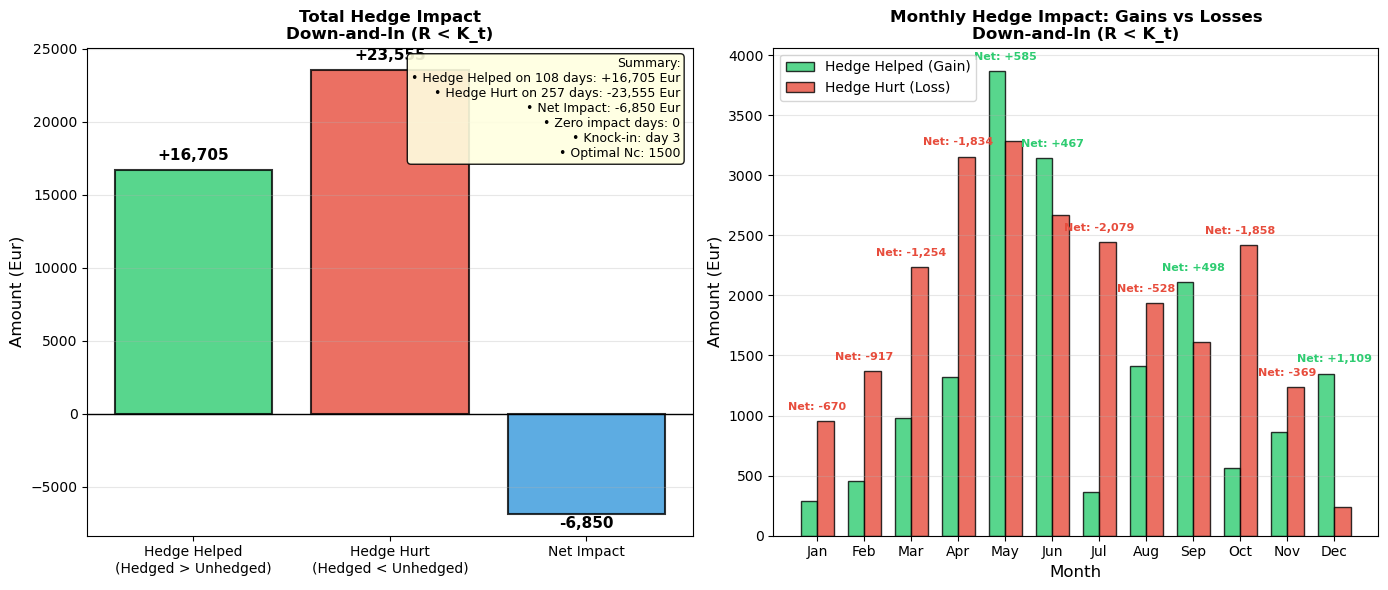

Plot saved: ../results/Barrier_down_and_in_Hedge_Impact_Analysis.png

DOWN-AND-IN (R < K_T) - HEDGE PERFORMANCE SUMMARY

Metric                                      Amount (Eur)       Days
-----------------------------------------------------------------
Hedge Helped (Hedged > Unhedged)                  16,705        108
Hedge Hurt (Hedged < Unhedged)                   -23,555        257
Zero Impact                                            0          0
-----------------------------------------------------------------
NET IMPACT (Gains - Losses)                       -6,850        365
-----------------------------------------------------------------


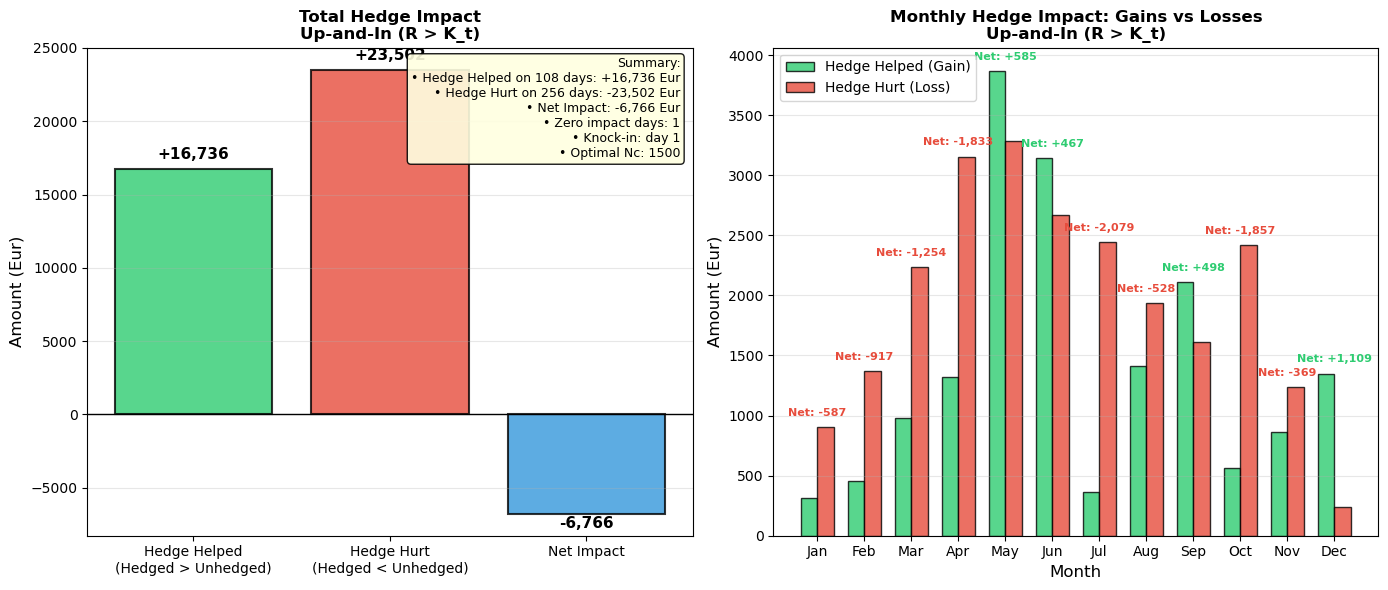

Plot saved: ../results/Barrier_up_and_in_Hedge_Impact_Analysis.png

UP-AND-IN (R > K_T) - HEDGE PERFORMANCE SUMMARY

Metric                                      Amount (Eur)       Days
-----------------------------------------------------------------
Hedge Helped (Hedged > Unhedged)                  16,736        108
Hedge Hurt (Hedged < Unhedged)                   -23,502        256
Zero Impact                                            0          1
-----------------------------------------------------------------
NET IMPACT (Gains - Losses)                       -6,766        364
-----------------------------------------------------------------


In [12]:
# =============================================================================
# Hedge Impact Analysis: Total Gains vs Losses from Hedging
# =============================================================================

def plot_hedge_impact_analysis(results):
    """Plot bar charts showing total gains vs losses from hedging"""
    
    daily_diff = results['cf_hedged'] - cf_u
    
    total_gain_helped = np.sum(daily_diff[daily_diff > 0])
    total_loss_hurt = np.sum(daily_diff[daily_diff < 0])
    net_impact = total_gain_helped + total_loss_hurt
    
    days_gain = len(daily_diff[daily_diff > 0])
    days_loss = len(daily_diff[daily_diff < 0])
    days_zero = len(daily_diff[daily_diff == 0])
    
    # Monthly breakdown
    dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    monthly_gain_amount = []
    monthly_loss_amount = []
    
    for month_idx in range(12):
        month_indices = np.where(dates_2022.month == month_idx + 1)[0]
        if len(month_indices) == 0:
            monthly_gain_amount.append(0)
            monthly_loss_amount.append(0)
            continue
        
        month_diff = daily_diff[month_indices]
        gain_amt = np.sum(month_diff[month_diff > 0])
        loss_amt = np.sum(month_diff[month_diff < 0])
        
        monthly_gain_amount.append(gain_amt)
        monthly_loss_amount.append(abs(loss_amt))
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # LEFT PLOT: Total yearly hedge impact
    categories = ['Hedge Helped\n(Hedged > Unhedged)', 
                  'Hedge Hurt\n(Hedged < Unhedged)',
                  'Net Impact']
    values = [total_gain_helped, abs(total_loss_hurt), net_impact]
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    
    bars = ax1.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + (max(values)*0.02 if val > 0 else min(values)*0.02),
                 f'{val:+,.0f}', ha='center', va='bottom' if val > 0 else 'top', 
                 fontsize=11, fontweight='bold')
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_ylabel('Amount (Eur)', fontsize=12)
    ax1.set_title(f'Total Hedge Impact\n{results["condition_name"]}', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    summary_text = (f'Summary:\n'
                    f'• Hedge Helped on {days_gain} days: +{total_gain_helped:,.0f} Eur\n'
                    f'• Hedge Hurt on {days_loss} days: {total_loss_hurt:,.0f} Eur\n'
                    f'• Net Impact: {net_impact:+,.0f} Eur\n'
                    f'• Zero impact days: {days_zero}\n'
                    f'• Knock-in: {"day " + str(results["actual_knock_day"]+1) if results["actual_knock_day"] < n_days else "NEVER"}\n'
                    f'• Optimal Nc: {results["Nc"]:.0f}')
    
    ax1.text(0.98, 0.98, summary_text, transform=ax1.transAxes, 
             fontsize=9, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    
    # RIGHT PLOT: Monthly breakdown
    x = np.arange(len(month_names))
    width = 0.35
    
    bars_gain = ax2.bar(x - width/2, monthly_gain_amount, width, 
                        label='Hedge Helped (Gain)', color='#2ecc71', alpha=0.8, edgecolor='black')
    bars_loss = ax2.bar(x + width/2, monthly_loss_amount, width, 
                        label='Hedge Hurt (Loss)', color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax2.set_xlabel('Month', fontsize=12)
    ax2.set_ylabel('Amount (Eur)', fontsize=12)
    ax2.set_title(f'Monthly Hedge Impact: Gains vs Losses\n{results["condition_name"]}', 
                  fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(month_names)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, (gain, loss) in enumerate(zip(monthly_gain_amount, monthly_loss_amount)):
        net = gain - loss
        color = '#2ecc71' if net > 0 else '#e74c3c' if net < 0 else 'gray'
        ax2.annotate(f'Net: {net:+,.0f}', 
                     xy=(i, max(gain, loss) + (max(monthly_gain_amount + monthly_loss_amount) * 0.02)),
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.savefig(f'../results/Barrier_{results["type"]}_Hedge_Impact_Analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: ../results/Barrier_{results['type']}_Hedge_Impact_Analysis.png")
    
    # Print summary
    print("\n" + "="*70)
    print(f"{results['condition_name'].upper()} - HEDGE PERFORMANCE SUMMARY")
    print("="*70)
    print(f"\n{'Metric':<35} {'Amount (Eur)':>20} {'Days':>10}")
    print("-"*65)
    print(f"{'Hedge Helped (Hedged > Unhedged)':<35} {total_gain_helped:>20,.0f} {days_gain:>10}")
    print(f"{'Hedge Hurt (Hedged < Unhedged)':<35} {total_loss_hurt:>20,.0f} {days_loss:>10}")
    print(f"{'Zero Impact':<35} {0:>20,.0f} {days_zero:>10}")
    print("-"*65)
    print(f"{'NET IMPACT (Gains - Losses)':<35} {net_impact:+20,.0f} {days_gain + days_loss:>10}")
    print("-"*65)

# Generate analyses
plot_hedge_impact_analysis(results_dni)
plot_hedge_impact_analysis(results_upi)


TESTING MAX < K_t BARRIER WITH DIFFERENT WINDOW SIZES

Pricing: Max(radiation) < K_t [cumulative (all days prior)]
  Knock-in rate (simulated): 39.4%
  Actual knock-in: NEVER
  Optimal Nc: 0.0
  MAPE: 27.13% → 27.13%
  Variance reduction: 0.0%

Pricing: Max(radiation) < K_t [rolling 3-day]
  Knock-in rate (simulated): 100.0%
  Actual knock-in: day 5
  Optimal Nc: 1499.4
  MAPE: 27.13% → 11.45%
  Variance reduction: 87.7%

Pricing: Max(radiation) < K_t [rolling 7-day]
  Knock-in rate (simulated): 99.5%
  Actual knock-in: day 116
  Optimal Nc: 1394.9
  MAPE: 27.13% → 15.62%
  Variance reduction: 67.6%

Pricing: Max(radiation) < K_t [rolling 14-day]
  Knock-in rate (simulated): 53.0%
  Actual knock-in: NEVER
  Optimal Nc: 0.0
  MAPE: 27.13% → 27.13%
  Variance reduction: 0.0%

Pricing: Max(radiation) < K_t [rolling 30-day]
  Knock-in rate (simulated): 39.5%
  Actual knock-in: NEVER
  Optimal Nc: 0.0
  MAPE: 27.13% → 27.13%
  Variance reduction: 0.0%

BEST PERFORMING WINDOW: rolling 3-day

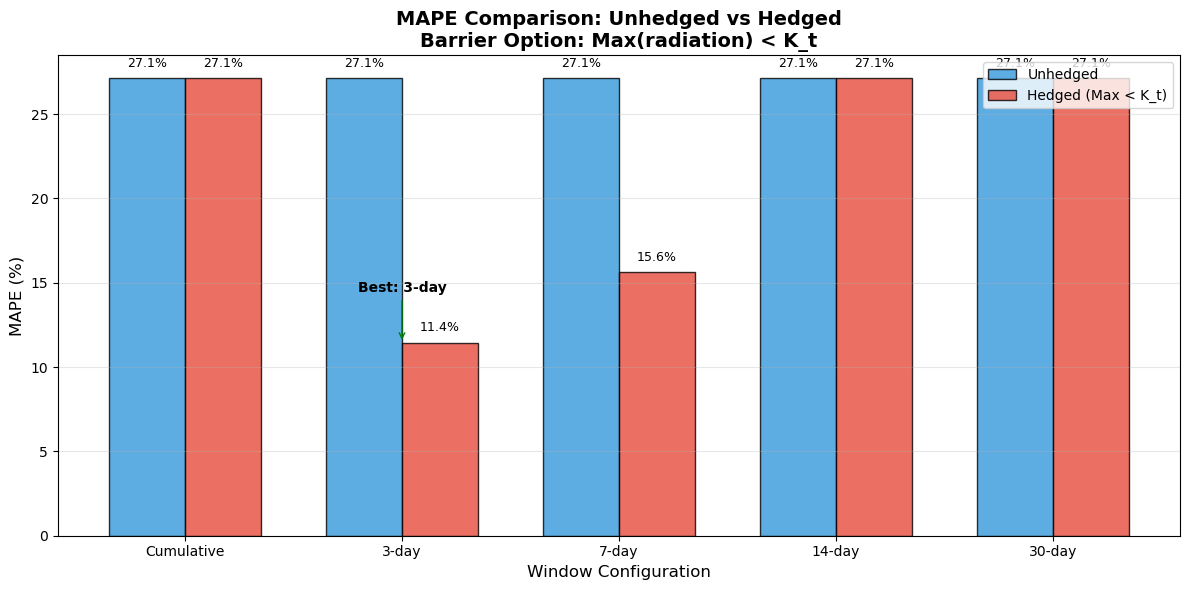

Plot saved: ../results/Barrier_MaxBelowK_MAPE_Comparison.png


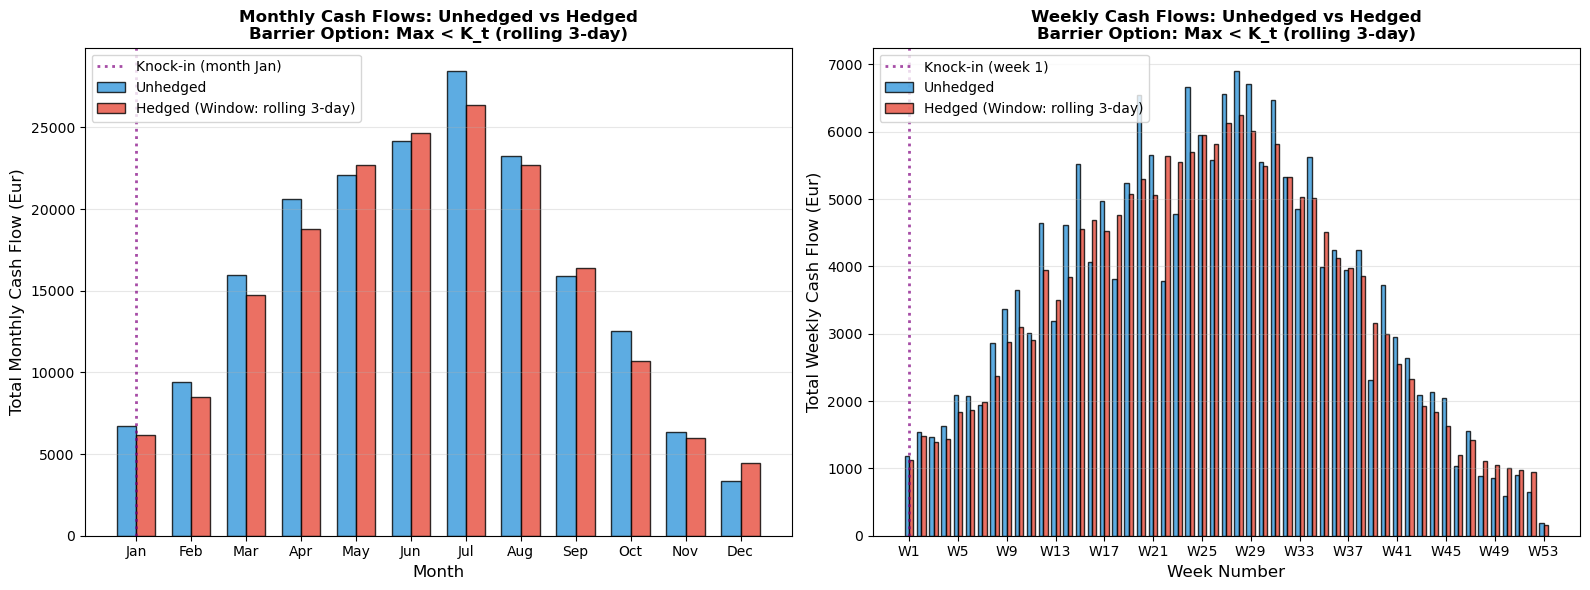

Plot saved: ../results/Barrier_MaxBelowK_Monthly_Weekly_Comparison.png


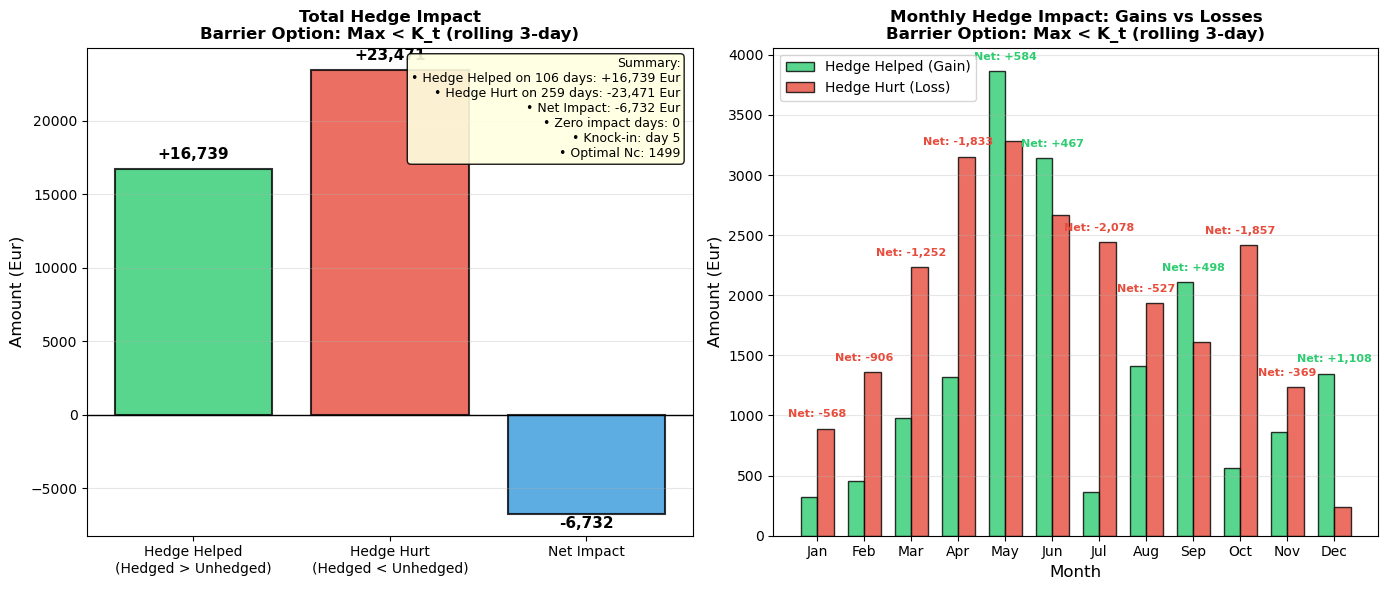

Plot saved: ../results/Barrier_MaxBelowK_Hedge_Impact_Analysis.png

MAX < K_t BARRIER (rolling 3-day) - HEDGE PERFORMANCE SUMMARY

Metric                                      Amount (Eur)       Days
-----------------------------------------------------------------
Hedge Helped (Hedged > Unhedged)                  16,739        106
Hedge Hurt (Hedged < Unhedged)                   -23,471        259
Zero Impact                                            0          0
-----------------------------------------------------------------


ValueError: Invalid format specifier '>20+,.0f' for object of type 'float'

In [13]:
# =============================================================================
# BARRIER OPTION 3: Max(production) < Seasonal Mean
# Knock-in when the maximum radiation over a lookback window is below K_t
# =============================================================================

def find_knock_day_max_below_K(series, K_series, window_size=None):
    """
    Find first day where max radiation over the window < K_t
    
    Parameters:
    - window_size: None = cumulative (all days up to current)
                   integer = rolling window of that many days
    """
    n = len(series)
    
    if window_size is None:
        # Cumulative max (all days up to current)
        rolling_max = np.maximum.accumulate(series)
    else:
        # Rolling window max
        rolling_max = np.zeros(n)
        for i in range(n):
            start = max(0, i - window_size + 1)
            rolling_max[i] = np.max(series[start:i+1])
    
    for i in range(n):
        if rolling_max[i] < K_series[i]:
            return i
    return n  # never knocks in


def price_max_below_barrier(all_R, R_actual, K_daily, window_size=None, 
                            tick=tick, n_days=n_days, n_sim=n_sim, 
                            cf_u=cf_u, cf_bench=cf_bench):
    """
    Price barrier option with knock-in condition:
    max(radiation over lookback window) < seasonal mean (K_t)
    
    Parameters:
    - window_size: None = cumulative (all days), integer = rolling window days
    """
    
    window_desc = "cumulative (all days prior)" if window_size is None else f"rolling {window_size}-day"
    condition_name = f"Max(radiation) < K_t [{window_desc}]"
    
    print(f"\n{'='*60}")
    print(f"Pricing: {condition_name}")
    print(f"{'='*60}")
    
    # -------------------------------------------------------------------------
    # Find knock-in day for each simulated path
    # -------------------------------------------------------------------------
    knock_days = np.full(n_sim, n_days, dtype=int)
    
    for sim in range(n_sim):
        knock_days[sim] = find_knock_day_max_below_K(all_R[sim], K_daily, window_size)
    
    knock_rate = 100 * np.mean(knock_days < n_days)
    print(f"  Knock-in rate (simulated): {knock_rate:.1f}%")
    
    # -------------------------------------------------------------------------
    # Calculate premium V0 for each day
    # -------------------------------------------------------------------------
    V0 = np.zeros(n_days)
    for T in range(n_days):
        indicator = (knock_days <= T).astype(float)
        payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
        V0[T] = np.mean(payoff_T * indicator)
    
    # -------------------------------------------------------------------------
    # Find actual knock-in day (historical)
    # -------------------------------------------------------------------------
    actual_knock_day = find_knock_day_max_below_K(R_actual, K_daily, window_size)
    
    ki_str = f"day {actual_knock_day+1}" if actual_knock_day < n_days else "NEVER"
    print(f"  Actual knock-in: {ki_str}")
    
    # -------------------------------------------------------------------------
    # Calculate actual payoff
    # -------------------------------------------------------------------------
    actual_payoff = np.zeros(n_days)
    if actual_knock_day < n_days:
        for T in range(actual_knock_day, n_days):
            actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
    
    # -------------------------------------------------------------------------
    # Calculate delta and optimal Nc
    # -------------------------------------------------------------------------
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    if denom > 1e-12:
        Nc = -np.sum((cf_u - cf_bench) * delta) / denom
        Nc = max(Nc, 0)
    else:
        Nc = 0
    
    print(f"  Optimal Nc: {Nc:.1f}")
    
    # -------------------------------------------------------------------------
    # Calculate hedged cash flows
    # -------------------------------------------------------------------------
    cf_hedged = cf_u + Nc * delta
    mape_u_val = mape(cf_u, cf_bench)
    mape_h_val = mape(cf_hedged, cf_bench)
    
    print(f"  MAPE: {mape_u_val:.2f}% → {mape_h_val:.2f}%")
    
    var_u = np.var(cf_u - cf_bench)
    var_h = np.var(cf_hedged - cf_bench)
    var_reduction = 100 * (1 - var_h / var_u) if var_u > 0 else 0
    print(f"  Variance reduction: {var_reduction:.1f}%")
    
    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------
    results = {
        'window_size': window_size,
        'window_desc': window_desc,
        'condition_name': condition_name,
        'V0': V0,
        'delta': delta,
        'Nc': Nc,
        'cf_hedged': cf_hedged,
        'mape_u': mape_u_val,
        'mape_h': mape_h_val,
        'var_reduction': var_reduction,
        'knock_rate': knock_rate,
        'actual_knock_day': actual_knock_day,
        'actual_payoff': actual_payoff,
        'cf_u': cf_u,
        'cf_bench': cf_bench,
        'K_daily': K_daily,
        'R_actual': R_actual,
        'knock_days_sim': knock_days
    }
    
    return results


# -----------------------------------------------------------------------------
# Test different window sizes for Max < K_t barrier
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("TESTING MAX < K_t BARRIER WITH DIFFERENT WINDOW SIZES")
print("="*70)

# Test cumulative (all days prior) and rolling windows
window_options = [None, 3, 7, 14, 30]  # None = cumulative, others = rolling days

max_below_results = {}
for window in window_options:
    results = price_max_below_barrier(all_R, R_actual, K_daily, window_size=window)
    max_below_results[window] = results

# Find best window based on variance reduction
best_window = max(max_below_results.keys(), 
                  key=lambda w: max_below_results[w]['var_reduction'])
best_max_below = max_below_results[best_window]

print(f"\n{'='*70}")
print(f"BEST PERFORMING WINDOW: {best_max_below['window_desc']}")
print(f"  Variance reduction: {best_max_below['var_reduction']:.1f}%")
print(f"  MAPE reduction: {best_max_below['mape_u']:.1f}% → {best_max_below['mape_h']:.1f}%")
print(f"  Nc: {best_max_below['Nc']:.0f}")
print(f"  Knock-in: day {best_max_below['actual_knock_day']+1}" if best_max_below['actual_knock_day'] < n_days else "  Knock-in: NEVER")
print(f"{'='*70}")


# =============================================================================
# PLOT: MAPE Comparison Across Different Window Sizes
# =============================================================================

def plot_mape_comparison_max_below(results_dict):
    """Bar chart comparing MAPE for different window configurations"""
    
    windows = []
    mape_u_vals = []
    mape_h_vals = []
    
    for window, results in results_dict.items():
        label = "Cumulative" if window is None else f"{window}-day"
        windows.append(label)
        mape_u_vals.append(results['mape_u'])
        mape_h_vals.append(results['mape_h'])
    
    x = np.arange(len(windows))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, mape_u_vals, width, label='Unhedged', 
                   color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, mape_h_vals, width, label='Hedged (Max < K_t)', 
                   color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax.set_xlabel('Window Configuration', fontsize=12)
    ax.set_ylabel('MAPE (%)', fontsize=12)
    ax.set_title('MAPE Comparison: Unhedged vs Hedged\nBarrier Option: Max(radiation) < K_t', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(windows)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Annotate best performer
    best_idx = np.argmin(mape_h_vals)
    ax.annotate(f'Best: {windows[best_idx]}', 
                xy=(x[best_idx], mape_h_vals[best_idx]),
                xytext=(x[best_idx], mape_h_vals[best_idx] + 3),
                ha='center', fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green'))
    
    plt.tight_layout()
    plt.savefig('../results/Barrier_MaxBelowK_MAPE_Comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: ../results/Barrier_MaxBelowK_MAPE_Comparison.png")

plot_mape_comparison_max_below(max_below_results)


# =============================================================================
# PLOT: Monthly and Weekly Cash Flow Comparison (Best Window)
# =============================================================================

def plot_monthly_weekly_comparison_max_below(results):
    """Create monthly and weekly bar charts comparing hedged vs unhedged"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # =========================================================================
    # LEFT PLOT: Monthly comparison
    # =========================================================================
    ax1 = axes[0]
    
    dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    monthly_unhedged = []
    monthly_hedged = []
    
    for month_idx in range(12):
        month_indices = np.where(dates_2022.month == month_idx + 1)[0]
        if len(month_indices) == 0:
            monthly_unhedged.append(0)
            monthly_hedged.append(0)
            continue
        
        monthly_unhedged.append(np.sum(cf_u[month_indices]))
        monthly_hedged.append(np.sum(results['cf_hedged'][month_indices]))
    
    x = np.arange(len(month_names))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, monthly_unhedged, width, label='Unhedged', 
                    color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = ax1.bar(x + width/2, monthly_hedged, width, 
                    label=f'Hedged (Window: {results["window_desc"]})', 
                    color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel('Total Monthly Cash Flow (Eur)', fontsize=12)
    ax1.set_title(f'Monthly Cash Flows: Unhedged vs Hedged\nBarrier Option: Max < K_t ({results["window_desc"]})', 
                  fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(month_names)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    if results['actual_knock_day'] < n_days:
        knock_month = dates_2022[results['actual_knock_day']].month - 1
        ax1.axvline(x=knock_month, color='purple', linestyle=':', linewidth=2, 
                    alpha=0.7, label=f'Knock-in (month {month_names[knock_month]})')
        ax1.legend(loc='upper left')
    
    # =========================================================================
    # RIGHT PLOT: Weekly comparison
    # =========================================================================
    ax2 = axes[1]
    
    n_weeks = (n_days + 6) // 7
    weekly_unhedged = []
    weekly_hedged = []
    week_labels = []
    
    for w in range(n_weeks):
        start_idx = w * 7
        end_idx = min((w + 1) * 7, n_days)
        weekly_unhedged.append(np.sum(cf_u[start_idx:end_idx]))
        weekly_hedged.append(np.sum(results['cf_hedged'][start_idx:end_idx]))
        week_labels.append(f'W{w+1}')
    
    x_weekly = np.arange(len(weekly_unhedged))
    width_weekly = 0.35
    
    bars1_w = ax2.bar(x_weekly - width_weekly/2, weekly_unhedged, width_weekly, 
                      label='Unhedged', color='#3498db', alpha=0.8, edgecolor='black')
    bars2_w = ax2.bar(x_weekly + width_weekly/2, weekly_hedged, width_weekly, 
                      label=f'Hedged (Window: {results["window_desc"]})', 
                      color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax2.set_xlabel('Week Number', fontsize=12)
    ax2.set_ylabel('Total Weekly Cash Flow (Eur)', fontsize=12)
    ax2.set_title(f'Weekly Cash Flows: Unhedged vs Hedged\nBarrier Option: Max < K_t ({results["window_desc"]})', 
                  fontsize=12, fontweight='bold')
    
    tick_positions = list(range(0, len(week_labels), 4))
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels([week_labels[i] for i in tick_positions])
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    if results['actual_knock_day'] < n_days:
        knock_week = results['actual_knock_day'] // 7
        ax2.axvline(x=knock_week, color='purple', linestyle=':', linewidth=2, 
                    alpha=0.7, label=f'Knock-in (week {knock_week+1})')
        ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f'../results/Barrier_MaxBelowK_Monthly_Weekly_Comparison.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: ../results/Barrier_MaxBelowK_Monthly_Weekly_Comparison.png")

plot_monthly_weekly_comparison_max_below(best_max_below)


# =============================================================================
# PLOT: Hedge Impact Analysis (Gains vs Losses)
# =============================================================================

def plot_hedge_impact_analysis_max_below(results):
    """Plot bar charts showing total gains vs losses from hedging"""
    
    daily_diff = results['cf_hedged'] - cf_u
    
    total_gain_helped = np.sum(daily_diff[daily_diff > 0])
    total_loss_hurt = np.sum(daily_diff[daily_diff < 0])
    net_impact = total_gain_helped + total_loss_hurt
    
    days_gain = len(daily_diff[daily_diff > 0])
    days_loss = len(daily_diff[daily_diff < 0])
    days_zero = len(daily_diff[daily_diff == 0])
    
    # Monthly breakdown
    dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    monthly_gain_amount = []
    monthly_loss_amount = []
    
    for month_idx in range(12):
        month_indices = np.where(dates_2022.month == month_idx + 1)[0]
        if len(month_indices) == 0:
            monthly_gain_amount.append(0)
            monthly_loss_amount.append(0)
            continue
        
        month_diff = daily_diff[month_indices]
        gain_amt = np.sum(month_diff[month_diff > 0])
        loss_amt = np.sum(month_diff[month_diff < 0])
        
        monthly_gain_amount.append(gain_amt)
        monthly_loss_amount.append(abs(loss_amt))
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # LEFT PLOT: Total yearly hedge impact
    categories = ['Hedge Helped\n(Hedged > Unhedged)', 
                  'Hedge Hurt\n(Hedged < Unhedged)',
                  'Net Impact']
    values = [total_gain_helped, abs(total_loss_hurt), net_impact]
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    
    bars = ax1.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + (max(values)*0.02 if val > 0 else min(values)*0.02),
                 f'{val:+,.0f}', ha='center', va='bottom' if val > 0 else 'top', 
                 fontsize=11, fontweight='bold')
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_ylabel('Amount (Eur)', fontsize=12)
    ax1.set_title(f'Total Hedge Impact\nBarrier Option: Max < K_t ({results["window_desc"]})', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    summary_text = (f'Summary:\n'
                    f'• Hedge Helped on {days_gain} days: +{total_gain_helped:,.0f} Eur\n'
                    f'• Hedge Hurt on {days_loss} days: {total_loss_hurt:,.0f} Eur\n'
                    f'• Net Impact: {net_impact:+,.0f} Eur\n'
                    f'• Zero impact days: {days_zero}\n'
                    f'• Knock-in: {"day " + str(results["actual_knock_day"]+1) if results["actual_knock_day"] < n_days else "NEVER"}\n'
                    f'• Optimal Nc: {results["Nc"]:.0f}')
    
    ax1.text(0.98, 0.98, summary_text, transform=ax1.transAxes, 
             fontsize=9, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    
    # RIGHT PLOT: Monthly breakdown
    x = np.arange(len(month_names))
    width = 0.35
    
    bars_gain = ax2.bar(x - width/2, monthly_gain_amount, width, 
                        label='Hedge Helped (Gain)', color='#2ecc71', alpha=0.8, edgecolor='black')
    bars_loss = ax2.bar(x + width/2, monthly_loss_amount, width, 
                        label='Hedge Hurt (Loss)', color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax2.set_xlabel('Month', fontsize=12)
    ax2.set_ylabel('Amount (Eur)', fontsize=12)
    ax2.set_title(f'Monthly Hedge Impact: Gains vs Losses\nBarrier Option: Max < K_t ({results["window_desc"]})', 
                  fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(month_names)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, (gain, loss) in enumerate(zip(monthly_gain_amount, monthly_loss_amount)):
        net = gain - loss
        color = '#2ecc71' if net > 0 else '#e74c3c' if net < 0 else 'gray'
        ax2.annotate(f'Net: {net:+,.0f}', 
                     xy=(i, max(gain, loss) + (max(monthly_gain_amount + monthly_loss_amount) * 0.02)),
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.savefig(f'../results/Barrier_MaxBelowK_Hedge_Impact_Analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: ../results/Barrier_MaxBelowK_Hedge_Impact_Analysis.png")
    
    # Print detailed summary
    print("\n" + "="*70)
    print(f"MAX < K_t BARRIER ({results['window_desc']}) - HEDGE PERFORMANCE SUMMARY")
    print("="*70)
    print(f"\n{'Metric':<35} {'Amount (Eur)':>20} {'Days':>10}")
    print("-"*65)
    print(f"{'Hedge Helped (Hedged > Unhedged)':<35} {total_gain_helped:>20,.0f} {days_gain:>10}")
    print(f"{'Hedge Hurt (Hedged < Unhedged)':<35} {total_loss_hurt:>20,.0f} {days_loss:>10}")
    print(f"{'Zero Impact':<35} {0:>20,.0f} {days_zero:>10}")
    print("-"*65)
    print(f"{'NET IMPACT (Gains - Losses)':<35} {net_impact:>20+,.0f} {days_gain + days_loss:>10}")
    print("-"*65)

plot_hedge_impact_analysis_max_below(best_max_below)


# =============================================================================
# SUMMARY TABLE: Compare All Three Barrier Types
# =============================================================================

print("\n" + "="*80)
print("SUMMARY COMPARISON: ALL THREE BARRIER OPTIONS")
print("="*80)

# Get your existing results (you'll need to adapt these variable names to match your notebook)
# For Down-and-In and Up-and-In, use your existing result variables (e.g., results_dni, results_upi)
# For Max < K_t, use best_max_below

print(f"\n{'Barrier Type':<35} {'Nc':>10} {'MAPE Unhedged':>15} {'MAPE Hedged':>15} {'Var Red %':>12} {'Knock-in Day':>15}")
print("-"*102)

# Down-and-In (you'll need to replace 'results_dni' with your actual variable name)
if 'results_dni' in dir():
    print(f"{'Down-and-In (R < K_t)':<35} {results_dni['Nc']:>10.0f} {results_dni['mape_u']:>14.1f}% {results_dni['mape_h']:>14.1f}% {results_dni['var_reduction']:>11.1f}% {results_dni['actual_knock_day']+1:>15}")

# Up-and-In (you'll need to replace 'results_upi' with your actual variable name)
if 'results_upi' in dir():
    print(f"{'Up-and-In (R > K_t)':<35} {results_upi['Nc']:>10.0f} {results_upi['mape_u']:>14.1f}% {results_upi['mape_h']:>14.1f}% {results_upi['var_reduction']:>11.1f}% {results_upi['actual_knock_day']+1:>15}")

# Max < K_t (Best window)
print(f"{f'Max < K_t ({best_max_below["window_desc"]})':<35} {best_max_below['Nc']:>10.0f} {best_max_below['mape_u']:>14.1f}% {best_max_below['mape_h']:>14.1f}% {best_max_below['var_reduction']:>11.1f}% {best_max_below['actual_knock_day']+1:>15}")

print("-"*102)

# Down&In Barrier SORAD (time varying)
Down and In & Using seasonal mean as barrier

In [5]:
# =============================================================================
# CLEAN BARRIER OPTIONS IMPLEMENTATION
# Two types: Down-and-In (DnI) and Up-and-In (UpI) with seasonal mean barrier
# Barrier = seasonal mean (K_t) - varies daily
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick

# -----------------------------------------------------------------------------
# 1. Ensure simulation data is available (reuse from earlier cells)
# -----------------------------------------------------------------------------
# These should already exist from your simulation:
# - all_R (simulated paths)
# - R_actual (historical GHI for 2022)
# - K_daily (daily strikes)
# - cf_u (unhedged cash flows)
# - cf_bench (benchmark cash flows)
# - n_days, n_sim

try:
    all_R.shape
    print("Using existing simulation data.")
except NameError:
    raise RuntimeError("Please run the monthly Asian simulation cell first to generate all_R.")

print(f"Simulation shape: {all_R.shape} paths x {n_days} days")

# -----------------------------------------------------------------------------
# 2. Barrier option pricing function
# -----------------------------------------------------------------------------
def price_barrier_option(all_R, R_actual, K_daily, barrier_type='down_and_in', 
                          barrier_multiplier=0.8, tick=tick):
    """
    Price barrier option with barrier = seasonal mean (K_t)
    
    Parameters:
    - barrier_type: 'down_and_in' (knocks in when R < K_t) or 'up_and_in' (knocks in when R > K_t)
    - barrier_multiplier: multiplier applied to K_t (e.g., 0.8 = 80% of K_t)
    """
    
    # Set barrier level (seasonal mean)
    barrier_level = K_daily
    
    # Determine knock-in condition
    if barrier_type == 'down_and_in':
        knock_condition = lambda series, K: series < K
        condition_name = "Down-and-In (R < K_t)"
    elif barrier_type == 'up_and_in':
        knock_condition = lambda series, K: series > K
        condition_name = "Up-and-In (R > K_t)"
    else:
        raise ValueError("barrier_type must be 'down_and_in' or 'up_and_in'")
    
    # -------------------------------------------------------------------------
    # Find knock-in day for each simulated path
    # -------------------------------------------------------------------------
    knock_days = np.full(n_sim, n_days, dtype=int)
    
    for sim in range(n_sim):
        for i in range(n_days):
            if knock_condition(all_R[sim, i], barrier_level[i]):
                knock_days[sim] = i
                break
    
    # -------------------------------------------------------------------------
    # Calculate premium V0 for each day
    # -------------------------------------------------------------------------
    V0 = np.zeros(n_days)
    for T in range(n_days):
        indicator = (knock_days <= T).astype(float)
        payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
        V0[T] = np.mean(payoff_T * indicator)
    
    # -------------------------------------------------------------------------
    # Find actual knock-in day (historical)
    # -------------------------------------------------------------------------
    actual_knock_day = n_days
    for i in range(n_days):
        if knock_condition(R_actual[i], barrier_level[i]):
            actual_knock_day = i
            break
    
    # -------------------------------------------------------------------------
    # Calculate actual payoff
    # -------------------------------------------------------------------------
    actual_payoff = np.zeros(n_days)
    if actual_knock_day < n_days:
        for T in range(actual_knock_day, n_days):
            actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
    
    # -------------------------------------------------------------------------
    # Calculate delta and optimal Nc
    # -------------------------------------------------------------------------
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    if denom > 1e-12:
        Nc = -np.sum((cf_u - cf_bench) * delta) / denom
        Nc = max(Nc, 0)  # No short selling
    else:
        Nc = 0
    
    # -------------------------------------------------------------------------
    # Calculate hedged cash flows
    # -------------------------------------------------------------------------
    cf_hedged = cf_u + Nc * delta
    mape_u_val = mape(cf_u, cf_bench)
    mape_h_val = mape(cf_hedged, cf_bench)
    
    # Performance metrics
    var_u = np.var(cf_u - cf_bench)
    var_h = np.var(cf_hedged - cf_bench)
    var_reduction = 100 * (1 - var_h / var_u) if var_u > 0 else 0
    
    knock_rate = 100 * np.mean(knock_days < n_days)
    
    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------
    results = {
        'type': barrier_type,
        'condition_name': condition_name,
        'V0': V0,
        'delta': delta,
        'Nc': Nc,
        'cf_hedged': cf_hedged,
        'mape_u': mape_u_val,
        'mape_h': mape_h_val,
        'var_reduction': var_reduction,
        'knock_rate': knock_rate,
        'actual_knock_day': actual_knock_day,
        'actual_payoff': actual_payoff,
        'cf_u': cf_u,
        'cf_bench': cf_bench,
        'K_daily': K_daily,
        'R_actual': R_actual,
        'knock_days_sim': knock_days
    }
    
    return results

# -----------------------------------------------------------------------------
# 3. Price both barrier types
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("PRICING BARRIER OPTIONS (Barrier = Seasonal Mean)")
print("="*70)

results_dni = price_barrier_option(all_R, R_actual, K_daily, barrier_type='down_and_in')
results_upi = price_barrier_option(all_R, R_actual, K_daily, barrier_type='up_and_in')

# Print results
for results in [results_dni, results_upi]:
    print(f"\n{results['condition_name']}:")
    print(f"  Knock-in rate (simulated): {results['knock_rate']:.1f}%")
    ki_str = f"day {results['actual_knock_day']+1}" if results['actual_knock_day'] < n_days else "NEVER"
    print(f"  Actual knock-in: {ki_str}")
    print(f"  Optimal Nc: {results['Nc']:.1f}")
    print(f"  MAPE: {results['mape_u']:.2f}% → {results['mape_h']:.2f}%")
    print(f"  Variance reduction: {results['var_reduction']:.1f}%")

RuntimeError: Please run the monthly Asian simulation cell first to generate all_R.

In [4]:
# =============================================================================
# Time‑varying barrier = seasonal mean (K_t)
# Consecutive‑day and cumulative shortfall variants
# =============================================================================

# Assumes all_R, R_actual, K_daily, cf_u, cf_bench, n_days are defined from earlier simulation

# ---------- Parameters ----------
tau_star = 2               # consecutive days below K_t required (try 1 or 2)
B = 10.0                   # cumulative shortfall threshold (kWh/m²) – adjust as needed

# -----------------------------------------------------------------------------
# 1. Consecutive‑day barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_consecutive_K(series, K_series, tau):
    streak = 0
    for i in range(len(series)):
        if series[i] < K_series[i]:
            streak += 1
            if streak >= tau:
                return i
        else:
            streak = 0
    return n_days

n_sim = all_R.shape[0]
print("Consecutive‑day barrier (H_t = K_t, tau={})".format(tau_star))
knock_sim = np.array([knock_consecutive_K(all_R[s], K_daily, tau_star) for s in range(n_sim)])

# Premiums
V0_cons = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cons[T] = np.mean(payoff_T * ind)

# Actual knock‑in
actual_knock_cons = knock_consecutive_K(R_actual, K_daily, tau_star)
actual_payoff_cons = np.zeros(n_days)
if actual_knock_cons < n_days:
    for T in range(actual_knock_cons, n_days):
        actual_payoff_cons[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cons = actual_payoff_cons - V0_cons
Nc_cons = -np.sum((cf_u - cf_bench) * delta_cons) / np.sum(delta_cons**2)
if Nc_cons < 0: Nc_cons = 0
cf_hedged_cons = cf_u + Nc_cons * delta_cons
mape_h_cons = mape(cf_hedged_cons, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cons+1 if actual_knock_cons < n_days else 'never'}")
print(f"  Nc = {Nc_cons:.1f}, MAPE_hedged = {mape_h_cons:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cons - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 2. Cumulative shortfall barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_cumulative_K(series, K_series, B):
    cum = 0.0
    for i in range(len(series)):
        cum += max(K_series[i] - series[i], 0)
        if cum > B:
            return i
    return n_days

print("\nCumulative shortfall barrier (H_t = K_t, B={})".format(B))
knock_sim_cum = np.array([knock_cumulative_K(all_R[s], K_daily, B) for s in range(n_sim)])

V0_cum = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cum[T] = np.mean(payoff_T * ind)

actual_knock_cum = knock_cumulative_K(R_actual, K_daily, B)
actual_payoff_cum = np.zeros(n_days)
if actual_knock_cum < n_days:
    for T in range(actual_knock_cum, n_days):
        actual_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cum = actual_payoff_cum - V0_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0: Nc_cum = 0
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_h_cum = mape(cf_hedged_cum, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")
print(f"  Nc = {Nc_cum:.1f}, MAPE_hedged = {mape_h_cum:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 3. Plot for the consecutive‑day case (should be close to daily vanilla)
# -----------------------------------------------------------------------------
# Reuse the plot style from the original barrier code
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n'),
]
dates_dense = pd.date_range('2022-01-01', '2022-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])  # need cal, but we can compute from K_daily if not available
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense)+1)
days_idx = np.arange(1, n_days+1)

fig, axes = plt.subplots(1, 2, figsize=(11,6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged_cons, 'Hedged (H_t=K_t, consecutive)')]:
    ax.scatter(days_idx[above], cf_vals[above], s=18, color='#2ecc71', alpha=0.85)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6)
    ax.set_title(title)
    ax.set_xlabel('Day of the year')
    ax.set_ylabel('Cash Flows (Eur)')
    ax.set_xlim(0,365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)
fig.legend(handles=legend_patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04))
fig.suptitle(f'Barrier SoRad (H_t=K_t, tau={tau_star}) – Nc={Nc_cons:.0f} | MAPE: {mape(cf_u, cf_bench):.1f}% → {mape_h_cons:.1f}%')
plt.tight_layout()
plt.savefig('../results/Figure_BSoRad_Kt_barrier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

NameError: name 'all_R' is not defined

## Up & In
Max production < seasonal mean

In [4]:

def max_below_threshold(series, H):
    """Returns True if all days in series are < H (max < H)"""
    return np.max(series) < H

# -----------------------------------------------------------------------------
# Loop over CF targets to find H and price barrier
# -----------------------------------------------------------------------------
results_barrier = {}

for CF_target in CF_targets:
    H = CF_target / CF_FACTOR

    # Simulated knock-in: TRUE if path's max radiation < H
    has_knock_sim = np.array([max_below_threshold(all_R[s], H) for s in range(n_sim)])
    knock_sim = np.where(has_knock_sim, 0, n_days)  # day 0 if knocked in, else never

    # Daily premiums V0[T]
    V0 = np.zeros(n_days)
    for T in range(n_days):
        ind = (knock_sim <= T).astype(float)
        payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
        V0[T] = np.mean(payoff_T * ind)

    # Actual knock-in (historical)
    actual_knock = 0 if max_below_threshold(R_actual, H) else n_days

    # Actual payoff
    actual_payoff = np.zeros(n_days)
    if actual_knock < n_days:
        for T in range(actual_knock, n_days):
            actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)

    # Optimal hedge ratio Nc
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    if denom > 1e-12:
        Nc = -np.sum((cf_u - cf_bench) * delta) / denom
        if Nc < 0:
            Nc = 0.0
    else:
        Nc = 0.0

    # Hedged cash flows
    cf_hedged = cf_u + Nc * delta

    # Performance metrics
    mape_u = mape(cf_u, cf_bench)
    mape_h = mape(cf_hedged, cf_bench)
    var_u = np.var(cf_u - cf_bench)
    var_red = 100 * (1 - np.var(cf_hedged - cf_bench) / var_u) if var_u > 0 else 0.0
    knock_frac = 100 * np.mean(has_knock_sim)

    results_barrier[CF_target] = {
        'H': H, 'Nc': Nc, 'cf_hedged': cf_hedged,
        'mape_u': mape_u, 'mape_h': mape_h, 'var_red': var_red,
        'knock_frac': knock_frac, 'actual_knock': actual_knock
    }

    # Print results
    print(f"  {CF_target:>12}  {H:>12.4f}  {100*H/np.median(K_daily):>9.1f}%  {knock_frac:>10.1f}%")
    ki_str = f"day {actual_knock+1} (R={R_actual[actual_knock]:.3f})" if actual_knock < n_days else "NEVER"
    print(f"    Actual knock-in: {ki_str}  |  Nc={Nc:.1f}  |  MAPE {mape_u:.2f}%→{mape_h:.2f}%  |  Var↓{var_red:.1f}%")


# -----------------------------------------------------------------------------
# Plot the results: Unhedged + 3 barrier variants
# -----------------------------------------------------------------------------
above = R_actual >= K_daily
days = np.arange(1, n_days + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True, sharex=True)
axes = axes.flatten()

panels = [
    (0, cf_u, "Unhedged", None),
] + [
    (idx + 1, results_barrier[cf]['cf_hedged'],
     f"H = {results_barrier[cf]['H']:.2f} kWh/m²  (CF target = {cf} €)\n"
     f"Nc={results_barrier[cf]['Nc']:.0f}  |  Var↓{results_barrier[cf]['var_red']:.1f}%",
     (cf, results_barrier[cf]))
    for idx, cf in enumerate(CF_targets)
]

for ax_idx, cf_vals, title, res_info in panels:
    ax = axes[ax_idx]
    ax.scatter(days[above], cf_vals[above], c='#2ecc71', s=10, zorder=2)
    ax.scatter(days[~above], cf_vals[~above], c='#e74c3c', s=10, zorder=2)
    ax.plot(days, cf_bench, 'k-', lw=1.5, label='Benchmark', zorder=3)

    if res_info is not None:
        cf_target, res = res_info
        ax.axhline(cf_target, color='navy', ls=':', lw=1.2, alpha=0.8,
                   label=f"CF target = {cf_target} €")
        if res['actual_knock'] < n_days:
            ax.axvline(res['actual_knock'] + 1, color='purple',
                       ls='--', lw=1.2, label=f"Knock-in day {res['actual_knock']+1}")
        mape_str = f"MAPE {res['mape_u']:.1f}% → {res['mape_h']:.1f}%"
    else:
        mape_str = f"MAPE {mape(cf_u, cf_bench):.1f}%"

    ax.set_title(f"{title}\n{mape_str}", fontsize=9)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Cash flow (€)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(
    f"CF-Implied Barrier SoRad — Max(radiation) < H\n"
    f"H = CF_target / {CF_FACTOR:.0f}  (CF_u = {CF_FACTOR:.0f} × R_n)",
    fontsize=11
)
plt.tight_layout()
plt.show()

NameError: name 'CF_targets' is not defined

In [5]:
# =============================================================================
# Barrier with "max < seasonal mean (K_t)" condition - with performance comparison
# =============================================================================

# Assumes all_R, R_actual, K_daily, cf_u, cf_bench, n_days, n_sim, tick are defined

print("\n" + "="*70)
print("Barrier with condition: max(radiation in period) < seasonal mean (K_t)")
print("="*70)

# -----------------------------------------------------------------------------
# Helper function: Find first day where rolling max falls below K_t
# -----------------------------------------------------------------------------
def knock_when_max_below_K(series, K_series, window=None):
    """
    Returns first day i where max(series over relevant window) < K_series[i].
    If window=None, uses max over all previous days (including current).
    If window is an integer, uses rolling max over that many days.
    """
    n = len(series)
    
    if window is None:
        # Cumulative max (all days up to current)
        rolling_max = np.maximum.accumulate(series)
    else:
        # Rolling window max
        rolling_max = np.zeros(n)
        for i in range(n):
            start = max(0, i - window + 1)
            rolling_max[i] = np.max(series[start:i+1])
    
    for i in range(n):
        if rolling_max[i] < K_series[i]:
            return i
    return n  # never knocks in

# -----------------------------------------------------------------------------
# Test different window sizes
# -----------------------------------------------------------------------------
window_options = [None, 3, 7, 14, 30]  # None = cumulative, others = rolling days
results_by_window = {}

for window in window_options:
    print(f"\n{'='*60}")
    print(f"Testing with window = {window if window else 'cumulative (all days prior)'}")
    print('-'*60)
    
    # Simulated knock-in days for all paths
    knock_sim = np.zeros(n_sim, dtype=int)
    for s in range(n_sim):
        knock_sim[s] = knock_when_max_below_K(all_R[s], K_daily, window)
    
    # Premium V0 for each possible knock-in day
    V0 = np.zeros(n_days)
    for T in range(n_days):
        ind = (knock_sim <= T).astype(float)
        payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
        V0[T] = np.mean(payoff_T * ind)
    
    # Actual knock-in (historical)
    actual_knock = knock_when_max_below_K(R_actual, K_daily, window)
    
    # Actual payoff
    actual_payoff = np.zeros(n_days)
    if actual_knock < n_days:
        for T in range(actual_knock, n_days):
            actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
    
    # Hedge ratio
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    if denom > 1e-12:
        Nc = -np.sum((cf_u - cf_bench) * delta) / denom
        if Nc < 0:
            Nc = 0.0
    else:
        Nc = 0.0
    
    # Hedged cash flows
    cf_hedged = cf_u + Nc * delta
    
    # Performance metrics
    mape_u = mape(cf_u, cf_bench)
    mape_h = mape(cf_hedged, cf_bench)
    var_u = np.var(cf_u - cf_bench)
    var_h = np.var(cf_hedged - cf_bench)
    var_red = 100 * (1 - var_h / var_u) if var_u > 0 else 0.0
    knock_frac = 100 * np.mean(knock_sim < n_days)
    
    # Cash flow performance metrics
    total_cf_u = np.sum(cf_u)
    total_cf_h = np.sum(cf_hedged)
    total_cf_bench = np.sum(cf_bench)
    
    # Mean Absolute Error (MAE) for cash flows
    mae_u = np.mean(np.abs(cf_u - cf_bench))
    mae_h = np.mean(np.abs(cf_hedged - cf_bench))
    mae_reduction = 100 * (1 - mae_h / mae_u) if mae_u > 0 else 0.0
    
    # Standard deviation of tracking error
    std_u = np.std(cf_u - cf_bench)
    std_h = np.std(cf_hedged - cf_bench)
    std_reduction = 100 * (1 - std_h / std_u) if std_u > 0 else 0.0
    
    # Maximum deviation
    max_dev_u = np.max(np.abs(cf_u - cf_bench))
    max_dev_h = np.max(np.abs(cf_hedged - cf_bench))
    
    # Store results
    results_by_window[window] = {
        'Nc': Nc, 'cf_hedged': cf_hedged, 'actual_knock': actual_knock,
        'mape_u': mape_u, 'mape_h': mape_h, 'var_red': var_red,
        'knock_frac': knock_frac, 'V0': V0, 'delta': delta,
        'total_cf_u': total_cf_u, 'total_cf_h': total_cf_h, 'total_cf_bench': total_cf_bench,
        'mae_u': mae_u, 'mae_h': mae_h, 'mae_reduction': mae_reduction,
        'std_u': std_u, 'std_h': std_h, 'std_reduction': std_reduction,
        'max_dev_u': max_dev_u, 'max_dev_h': max_dev_h
    }
    
    # Print detailed results
    ki_str = f"day {actual_knock+1}" if actual_knock < n_days else "NEVER"
    print(f"  Knock-in rate (simulated): {knock_frac:.1f}%")
    print(f"  Actual knock-in: {ki_str}")
    print(f"  Nc = {Nc:.1f}")
    print(f"  MAPE: {mape_u:.2f}% → {mape_h:.2f}%")
    print(f"  Variance reduction: {var_red:.1f}%")
    print(f"  MAE (€): {mae_u:.2f} → {mae_h:.2f} (↓{mae_reduction:.1f}%)")
    print(f"  Std Dev (€): {std_u:.2f} → {std_h:.2f} (↓{std_reduction:.1f}%)")
    print(f"  Total CF (€): {total_cf_u:.0f} (unhedged) vs {total_cf_h:.0f} (hedged) vs {total_cf_bench:.0f} (benchmark)")

# -----------------------------------------------------------------------------
# Find best window based on variance reduction
# -----------------------------------------------------------------------------
best_window = max(results_by_window.keys(), 
                  key=lambda w: results_by_window[w]['var_red'])
best_results = results_by_window[best_window]

print(f"\n{'='*70}")
print(f"Best performing window: {best_window if best_window else 'cumulative'}")
print(f"  Variance reduction: {best_results['var_red']:.1f}%")
print(f"  MAPE reduction: {best_results['mape_u']:.1f}% → {best_results['mape_h']:.1f}%")
print(f"  MAE reduction: {best_results['mae_u']:.2f}€ → {best_results['mae_h']:.2f}€")
print(f"  Std Dev reduction: {best_results['std_u']:.2f}€ → {best_results['std_h']:.2f}€")

# -----------------------------------------------------------------------------
# Plot 1: Daily Cash Flows Comparison (KEEP THIS GRAPH)
# -----------------------------------------------------------------------------
above = R_actual >= K_daily
days = np.arange(1, n_days + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unhedged plot
ax = axes[0]
ax.scatter(days[above], cf_u[above], s=18, color='#2ecc71', alpha=0.85, label='R_n >= K_n')
ax.scatter(days[~above], cf_u[~above], s=18, color='#e74c3c', alpha=0.85, label='R_n < K_n')
ax.plot(days, cf_bench, 'k-', lw=1.6, label='Benchmark')
ax.set_title(f'Unhedged\nMAPE: {mape(cf_u, cf_bench):.1f}% | MAE: {best_results["mae_u"]:.2f}€')
ax.set_xlabel('Day of the year')
ax.set_ylabel('Cash Flow (€)')
ax.set_xlim(0, 365)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.25)
ax.legend()

# Hedged plot (best window)
ax = axes[1]
ax.scatter(days[above], best_results['cf_hedged'][above], s=18, color='#2ecc71', alpha=0.85, label='R_n >= K_n')
ax.scatter(days[~above], best_results['cf_hedged'][~above], s=18, color='#e74c3c', alpha=0.85, label='R_n < K_n')
ax.plot(days, cf_bench, 'k-', lw=1.6, label='Benchmark')
ax.set_title(f'Hedged (window = {best_window if best_window else "cumulative"})\nMAPE: {best_results["mape_h"]:.1f}% | MAE: {best_results["mae_h"]:.2f}€')
ax.set_xlabel('Day of the year')
ax.set_ylabel('Cash Flow (€)')
ax.set_xlim(0, 365)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.25)
ax.legend()

# Add knock-in annotation if applicable
if best_results['actual_knock'] < n_days:
    axes[1].axvline(best_results['actual_knock'] + 1, color='red', 
                    linestyle='--', alpha=0.7, 
                    label=f'Knock-in: day {best_results["actual_knock"]+1}')
    axes[1].legend()

fig.suptitle(f'Max-Below-Seasonal-Mean Barrier | Nc = {best_results["Nc"]:.0f}', fontsize=12)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Plot 2: Weekly Bar Chart (Unhedged vs Hedged) - Similar to your Asian style
# -----------------------------------------------------------------------------
# Define weeks (7‑day periods, last week may be shorter)
n_weeks = (n_days + 6) // 7
week_starts = list(range(0, n_days, 7))
week_ends = [min(s+7, n_days) for s in week_starts]
weeks = list(zip(week_starts, week_ends))

print(f"\nNumber of weeks in {year}: {len(weeks)}")

# Aggregate weekly cash flows
weekly_cf_u = np.array([np.sum(cf_u[s:e]) for (s, e) in weeks])
weekly_cf_hedged = np.array([np.sum(best_results['cf_hedged'][s:e]) for (s, e) in weeks])
weekly_cf_bench = np.array([np.sum(cf_bench[s:e]) for (s, e) in weeks])

week_numbers = np.arange(1, n_weeks+1)
width = 0.35

# Create the bar chart
fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(week_numbers - width/2, weekly_cf_u, width, label='Unhedged', color='blue', alpha=0.7)
bars2 = ax.bar(week_numbers + width/2, weekly_cf_hedged, width, label='Hedged', color='green', alpha=0.7)
ax.plot(week_numbers, weekly_cf_bench, 'r--', label='Benchmark', linewidth=2)

# Mark knock-in week if applicable
if best_results['actual_knock'] < n_days:
    knock_week = best_results['actual_knock'] // 7 + 1
    ax.axvline(knock_week, color='purple', linestyle=':', linewidth=2, 
               label=f'Knock-in (week {knock_week})')

ax.set_xlabel('Week number')
ax.set_ylabel('Weekly Cash Flow (€)')
ax.set_title(f'Barrier Hedge (max < K_t, window={best_window}) – Weekly Aggregation | Nc = {best_results["Nc"]:.0f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print weekly MAPE
mape_u_week = 100 * np.mean(np.abs((weekly_cf_u - weekly_cf_bench) / weekly_cf_bench))
mape_h_week = 100 * np.mean(np.abs((weekly_cf_hedged - weekly_cf_bench) / weekly_cf_bench))
print(f"\nWeekly MAPE unhedged: {mape_u_week:.2f}%")
print(f"Weekly MAPE hedged:   {mape_h_week:.2f}%")

# -----------------------------------------------------------------------------
# Plot 3: Positive vs Negative Impact Bar Graph
# -----------------------------------------------------------------------------
# Calculate weekly tracking errors
tracking_u = weekly_cf_u - weekly_cf_bench
tracking_h = weekly_cf_hedged - weekly_cf_bench

# Determine where hedging helped vs hurt
abs_u = np.abs(tracking_u)
abs_h = np.abs(tracking_h)
helped = abs_h < abs_u
hurt = abs_h > abs_u
same = abs_h == abs_u

# Create data for bar graph
categories = ['Hedging Helped', 'Hedging Hurt', 'No Change']
counts = [np.sum(helped), np.sum(hurt), np.sum(same)]
percentages = [100 * c / len(helped) for c in counts]

# Also calculate the magnitude of improvement/degradation
improvement_magnitude = abs_u[helped] - abs_h[helped] if np.sum(helped) > 0 else np.array([])
degradation_magnitude = abs_h[hurt] - abs_u[hurt] if np.sum(hurt) > 0 else np.array([])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Count of weeks (bar chart)
bars = ax1.bar(categories, counts, color=['green', 'red', 'gray'], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Impact Category')
ax1.set_ylabel('Number of Weeks')
ax1.set_title('Hedging Impact Distribution (Weekly)')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{count}\n({percentages[0] if count == counts[0] else percentages[1] if count == counts[1] else percentages[2]:.0f}%)',
             ha='center', va='bottom', fontsize=10)

# Subplot 2: Magnitude of impact (bar chart)
x_pos = np.arange(2)
magnitudes = [
    np.mean(improvement_magnitude) if len(improvement_magnitude) > 0 else 0,
    np.mean(degradation_magnitude) if len(degradation_magnitude) > 0 else 0
]
std_errors = [
    np.std(improvement_magnitude) if len(improvement_magnitude) > 0 else 0,
    np.std(degradation_magnitude) if len(degradation_magnitude) > 0 else 0
]

bars2 = ax2.bar(x_pos, magnitudes, color=['green', 'red'], alpha=0.7, edgecolor='black', 
                yerr=std_errors, capsize=5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['When Hedging Helped', 'When Hedging Hurt'])
ax2.set_ylabel('Absolute Error Reduction (€)')
ax2.set_title('Average Impact Magnitude (Weekly)')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, mag in zip(bars2, magnitudes):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{mag:.1f}€', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("POSITIVE vs NEGATIVE IMPACT SUMMARY")
print("="*60)
print(f"\nTotal weeks analyzed: {len(helped)}")
print(f"Weeks where hedging helped: {np.sum(helped)} ({100*np.sum(helped)/len(helped):.1f}%)")
print(f"Weeks where hedging hurt: {np.sum(hurt)} ({100*np.sum(hurt)/len(hurt):.1f}%)")
print(f"Weeks with no change: {np.sum(same)} ({100*np.sum(same)/len(same):.1f}%)")

if len(improvement_magnitude) > 0:
    print(f"\nAverage improvement when hedging helped: {np.mean(improvement_magnitude):.2f}€")
    print(f"Maximum improvement: {np.max(improvement_magnitude):.2f}€")
if len(degradation_magnitude) > 0:
    print(f"Average degradation when hedging hurt: {np.mean(degradation_magnitude):.2f}€")
    print(f"Maximum degradation: {np.max(degradation_magnitude):.2f}€")

# Net benefit
total_abs_u = np.sum(abs_u)
total_abs_h = np.sum(abs_h)
net_benefit = total_abs_u - total_abs_h
print(f"\nTotal absolute error (unhedged): {total_abs_u:.2f}€")
print(f"Total absolute error (hedged): {total_abs_h:.2f}€")
print(f"Net benefit (reduction): {net_benefit:.2f}€")

# -----------------------------------------------------------------------------
# Optional: Add a simple line plot comparing cumulative absolute error
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

cumulative_abs_u = np.cumsum(abs_u)
cumulative_abs_h = np.cumsum(abs_h)

ax.plot(week_numbers, cumulative_abs_u, 'b-', linewidth=1.5, label='Unhedged (cumulative absolute error)')
ax.plot(week_numbers, cumulative_abs_h, 'g-', linewidth=1.5, label='Hedged (cumulative absolute error)')
ax.fill_between(week_numbers, cumulative_abs_h, cumulative_abs_u, 
                where=(cumulative_abs_h < cumulative_abs_u), 
                color='green', alpha=0.3, label='Benefit from hedging')
ax.fill_between(week_numbers, cumulative_abs_u, cumulative_abs_h, 
                where=(cumulative_abs_u < cumulative_abs_h), 
                color='red', alpha=0.3, label='Loss from hedging')

ax.set_xlabel('Week number')
ax.set_ylabel('Cumulative Absolute Error (€)')
ax.set_title('Cumulative Tracking Error: Unhedged vs Hedged')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Knock-in occurred on day {best_results['actual_knock']+1}" if best_results['actual_knock'] < n_days else "\n✅ No knock-in occurred")


Barrier with condition: max(radiation in period) < seasonal mean (K_t)

Testing with window = cumulative (all days prior)
------------------------------------------------------------


NameError: name 'n_sim' is not defined

Simulating 5000 paths for 2022...
Done.

CF_FACTOR = 120.0  →  H = CF / 120.0
 CF target (€)    H (kWh/m²)     H/K_med    Knock-in%
-------------------------------------------------------
           200        1.6667       39.0%       100.0%
    Actual knock-in: day 3 (R=1.065)  |  Nc=53.5  |  MAPE 27.13%→25.74%  |  Var↓6.9%
           400        3.3333       78.1%       100.0%
    Actual knock-in: day 1 (R=1.731)  |  Nc=53.5  |  MAPE 27.13%→25.74%  |  Var↓6.9%
           600        5.0000      117.1%       100.0%
    Actual knock-in: day 1 (R=1.731)  |  Nc=53.5  |  MAPE 27.13%→25.74%  |  Var↓6.9%


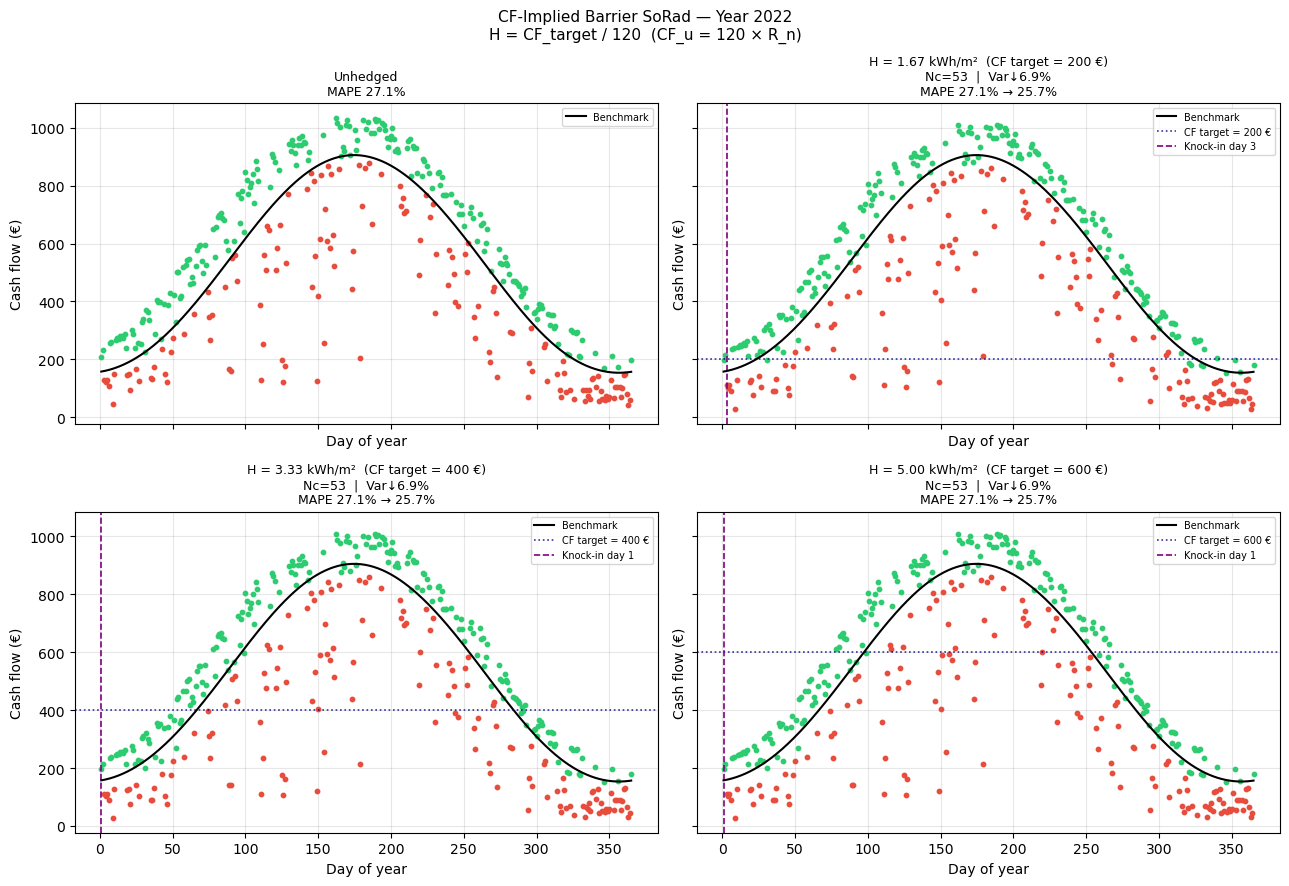

Plot saved.


In [6]:
# =============================================================================
# CF-Implied Barrier SoRad  –  fixed version
# H derived from target cash-flow level:  H = CF_target / CF_FACTOR
# Easily switch TEST_YEAR to 2010 (cloudy) to see non-zero Nc
# =============================================================================
# NOTE: re-runs simulation if TEST_YEAR differs from the one already in memory.
# Set TEST_YEAR = 2022 to reproduce the original applied-year behavior.
# Set TEST_YEAR = 2010 for a cloudy year with meaningful hedging.
TEST_YEAR = 2022     # <-- change to 2010 to see Nc > 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick
from solarrpy.seasonalSolarFunctions import SeasonalSolarFunctions
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# ---------- helpers (same as simulation cell) --------------------------------
def compute_H0(date, lat=44.4949, alt=71):
    ssf = SeasonalSolarFunctions(method="spencer")
    return ssf.Hon(date.dayofyear, lat, alt)

def clearsky_C(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    return (cal.delta[0] + cal.delta[1]*compute_H0(date)
            + cal.delta[2]*np.sin(omega*t) + cal.delta[3]*np.cos(omega*t))

def seasonal_mean_Y(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    return cal.a[0] + cal.a[1]*np.sin(omega*t) + cal.a[2]*np.cos(omega*t)

def inverse_transform(Y, date, cal):
    C = clearsky_C(date, cal)
    return C * (1 - cal.alpha - cal.beta * np.exp(-Y))

def transform(R, date, cal):
    C = clearsky_C(date, cal)
    inside = 1 - cal.alpha - R / C
    return np.log(np.log(cal.beta) - np.log(max(inside, 1e-8)))

# ---------- (re-)calibrate if needed -----------------------------------------
df_sim = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df_sim = df_sim.drop(columns=['H0'], errors='ignore')
cal_sim = calibrate_window(
    df_sim[df_sim['Year'] <= TEST_YEAR - 1].copy(),
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': 44.4949}, train_end_year=TEST_YEAR - 1,
)

# ---------- simulate ---------------------------------------------------------
N_SIM   = 5000
is_leap = (TEST_YEAR % 4 == 0 and (TEST_YEAR % 100 != 0 or TEST_YEAR % 400 == 0))
n_days  = 366 if is_leap else 365
dates   = pd.date_range(f'{TEST_YEAR}-01-01', periods=n_days, freq='D')
omega   = 2 * np.pi / 365

Ybar_t      = np.array([seasonal_mean_Y(d, cal_sim) for d in dates])
int_I       = integral_sigma_numeric(cal_sim.theta, cal_sim.c)
int_J       = integral_sigma2_formula(cal_sim.theta, cal_sim.gamma)
ns          = dates.dayofyear.values.astype(float)
I_daily     = int_I(ns-1, ns, ns).ravel()
J_daily     = int_J(ns-1, ns, ns).ravel()

monthly_df  = cal_sim.monthly_mixture.set_index('Month')
p_m   = monthly_df['p'].values
mu0_m = monthly_df['mu0'].values;  mu1_m = monthly_df['mu1'].values
s0_m  = monthly_df['sd0'].values;  s1_m  = monthly_df['sd1'].values

prev_date  = pd.Timestamp(f'{TEST_YEAR-1}-12-31')
prev_R     = df_sim[df_sim['date'] == prev_date]['GHI'].values[0]
Y_prev     = transform(prev_R, prev_date, cal_sim)

np.random.seed(42)
print(f"Simulating {N_SIM} paths for {TEST_YEAR}...")
all_R_sim = np.zeros((N_SIM, n_days))
for s in range(N_SIM):
    Y_curr = Y_prev
    for i in range(n_days):
        m     = dates[i].month - 1
        B     = np.random.binomial(1, p_m[m])
        mu_B  = mu1_m[m] if B else mu0_m[m]
        sig_B = s1_m[m]  if B else s0_m[m]
        Ybar_prev_i = seasonal_mean_Y(dates[0] - pd.Timedelta(days=1), cal_sim) if i == 0 else Ybar_t[i-1]
        Y_next = (Ybar_t[i]
                  + (Y_curr - Ybar_prev_i) * np.exp(-cal_sim.theta)
                  + mu_B * I_daily[i]
                  + sig_B * np.sqrt(J_daily[i]) * np.random.normal())
        all_R_sim[s, i] = inverse_transform(Y_next, dates[i], cal_sim)
        Y_curr = Y_next
print("Done.")

df_year    = df_sim[df_sim['Year'] == TEST_YEAR].sort_values('date').reset_index(drop=True)
R_actual   = df_year['GHI'].values
K_daily    = np.array([daily_strike(row['date'], cal_sim) for _, row in df_year.iterrows()])
cf_u       = unhedged_cf(R_actual)
cf_bench   = benchmark_cf(K_daily)

# =============================================================================
# CF-to-H mapping and pricing
# =============================================================================
CF_FACTOR  = 0.15 * 10000 * 0.08          # = 120
CF_targets = [200, 400, 600]

print(f"\nCF_FACTOR = {CF_FACTOR:.1f}  →  H = CF / {CF_FACTOR:.1f}")
print(f"{'CF target (€)':>14}  {'H (kWh/m²)':>12}  {'H/K_med':>10}  {'Knock-in%':>11}")
print("-" * 55)

results = {}
for CF_target in CF_targets:
    H = CF_target / CF_FACTOR

    # simulated knock-in (tau=1: first day below H)
    hit       = all_R_sim < H                          # (N_SIM, n_days) bool
    has_hit   = hit.any(axis=1)
    knock_sim = np.where(has_hit, hit.argmax(axis=1), n_days)

    # daily premiums
    V0 = np.array([
        np.mean(tick * np.maximum(K_daily[T] - all_R_sim[:, T], 0) * (knock_sim <= T))
        for T in range(n_days)
    ])

    # actual knock-in
    below_idx    = np.where(R_actual < H)[0]
    actual_knock = below_idx[0] if len(below_idx) else n_days

    actual_payoff = np.zeros(n_days)
    if actual_knock < n_days:
        actual_payoff[actual_knock:] = tick * np.maximum(K_daily[actual_knock:] - R_actual[actual_knock:], 0)

    # optimal Nc
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    Nc    = max(-np.sum((cf_u - cf_bench) * delta) / denom if denom > 1e-12 else 0.0, 0.0)

    cf_hedged = cf_u + Nc * delta
    mape_u    = mape(cf_u, cf_bench)
    mape_h    = mape(cf_hedged, cf_bench)
    var_u     = np.var(cf_u - cf_bench)
    var_red   = 100*(1 - np.var(cf_hedged - cf_bench)/var_u) if var_u > 0 else 0.0
    kfrac     = 100 * np.mean(knock_sim < n_days)

    results[CF_target] = dict(H=H, Nc=Nc, cf_hedged=cf_hedged, mape_u=mape_u,
                               mape_h=mape_h, var_red=var_red, knock_frac=kfrac,
                               actual_knock=actual_knock)

    print(f"  {CF_target:>12}  {H:>12.4f}  {100*H/np.median(K_daily):>9.1f}%  {kfrac:>10.1f}%")
    ki_str = f"day {actual_knock+1} (R={R_actual[actual_knock]:.3f})" if actual_knock < n_days else "NEVER"
    print(f"    Actual knock-in: {ki_str}  |  Nc={Nc:.1f}  |  MAPE {mape_u:.2f}%→{mape_h:.2f}%  |  Var↓{var_red:.1f}%")

# =============================================================================
# Plot: 2×2 grid — Unhedged + three barrier variants
# =============================================================================
above = R_actual >= K_daily
days  = np.arange(1, n_days + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True, sharex=True)
axes = axes.flatten()

panels = [
    (0, cf_u,    "Unhedged",  None),
] + [
    (idx+1, results[cf]['cf_hedged'],
     f"H = {results[cf]['H']:.2f} kWh/m²  (CF target = {cf} €)\n"
     f"Nc={results[cf]['Nc']:.0f}  |  Var↓{results[cf]['var_red']:.1f}%",
     (cf, results[cf]))
    for idx, cf in enumerate(CF_targets)
]

for ax_idx, cf_vals, title, res_info in panels:
    ax = axes[ax_idx]
    ax.scatter(days[ above], cf_vals[ above], c='#2ecc71', s=10, zorder=2)
    ax.scatter(days[~above], cf_vals[~above], c='#e74c3c', s=10, zorder=2)
    ax.plot(days, cf_bench, 'k-', lw=1.5, label='Benchmark', zorder=3)

    if res_info is not None:
        cf_target, res = res_info
        ax.axhline(cf_target, color='navy', ls=':', lw=1.2, alpha=0.8,
                   label=f"CF target = {cf_target} €")
        ax.axvline(res['H'] * CF_FACTOR / CF_FACTOR,   # just for clarity
                   color='none')                         # placeholder
        if res['actual_knock'] < n_days:
            ax.axvline(res['actual_knock'] + 1, color='purple',
                       ls='--', lw=1.2,
                       label=f"Knock-in day {res['actual_knock']+1}")
        mape_str = f"MAPE {res['mape_u']:.1f}% → {res['mape_h']:.1f}%"
    else:
        mape_str = f"MAPE {mape(cf_u, cf_bench):.1f}%"

    ax.set_title(f"{title}\n{mape_str}", fontsize=9)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Cash flow (€)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(
    f"CF-Implied Barrier SoRad — Year {TEST_YEAR}\n"
    f"H = CF_target / {CF_FACTOR:.0f}  (CF_u = {CF_FACTOR:.0f} × R_n)",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"barrier_cf_implied_{TEST_YEAR}.png", dpi=150)
plt.show()
print("Plot saved.")

In [7]:
tau_star = 2               # consecutive days below K_t required to knock in

# -----------------------------------------------------------------------------
# 1. Consecutive‑day knock‑in function (using K_t as barrier)
# -----------------------------------------------------------------------------
def knock_consecutive_K(series, K_series, tau):
    streak = 0
    for i in range(len(series)):
        if series[i] < K_series[i]:
            streak += 1
            if streak >= tau:
                return i          # knock‑in day (0‑based)
        else:
            streak = 0
    return n_days                # never knocks in

# -----------------------------------------------------------------------------
# 2. Monte Carlo pricing: premium V0 for each possible knock‑in day T
# -----------------------------------------------------------------------------
n_sim = all_R.shape[0]
print("Pricing daily barrier (H_t = K_t, consecutive days, tau={})".format(tau_star))

# Simulated knock‑in days for all paths
knock_sim = np.array([knock_consecutive_K(all_R[s], K_daily, tau_star) for s in range(n_sim)])

# Premium V0[T] = expected payoff if knock‑in occurs on or before day T
V0 = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim <= T).astype(float)                     # indicator: path knocked in by T
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)  # payoff at day T (European)
    V0[T] = np.mean(payoff_T * ind)

# -----------------------------------------------------------------------------
# 3. Actual path (historical) – knock‑in day and payoff delta
# -----------------------------------------------------------------------------
actual_knock = knock_consecutive_K(R_actual, K_daily, tau_star)

# Actual payoff if knocked in (otherwise zero)
actual_payoff = np.zeros(n_days)
if actual_knock < n_days:
    for T in range(actual_knock, n_days):
        actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)

# Delta = actual payoff - premium (daily time series)
delta = actual_payoff - V0

print(f"Actual knock‑in day: {actual_knock+1 if actual_knock < n_days else 'never'}")

# -----------------------------------------------------------------------------
# 4. Optimal hedge ratio Nc (minimises variance of hedged CF vs benchmark)
# -----------------------------------------------------------------------------
diff_u = cf_u - cf_bench
Nc = -np.sum(diff_u * delta) / np.sum(delta**2)
if Nc < 0:
    Nc = 0
print(f"Optimal number of barrier contracts: {Nc:.1f}")

# -----------------------------------------------------------------------------
# 5. Hedged cash flows (daily)
# -----------------------------------------------------------------------------
cf_hedged = cf_u + Nc * delta

# -----------------------------------------------------------------------------
# 6. Daily MAPE (Mean Absolute Percentage Error) relative to benchmark
# -----------------------------------------------------------------------------
def mape(series, benchmark):
    # avoid division by zero: ignore days where benchmark is zero
    mask = benchmark != 0
    return 100 * np.mean(np.abs((series[mask] - benchmark[mask]) / benchmark[mask]))

mape_u = mape(cf_u, cf_bench)
mape_h = mape(cf_hedged, cf_bench)
print(f"Daily MAPE – unhedged: {mape_u:.2f}%, hedged: {mape_h:.2f}%")

# Variance reduction
var_u = np.var(cf_u - cf_bench)
var_h = np.var(cf_hedged - cf_bench)
var_reduction = 100 * (1 - var_h / var_u)
print(f"Variance reduction: {var_reduction:.1f}%")

# -----------------------------------------------------------------------------
# 7. Plot: daily unhedged vs hedged cash flows (with benchmark line)
# -----------------------------------------------------------------------------
days = np.arange(1, n_days + 1)   # day numbers (1‑based for plotting)

# Optionally create a DataFrame with dates for nicer x‑axis
# dates = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')[:n_days]

fig, ax = plt.subplots(figsize=(14, 6))

# Plot unhedged and hedged as lines (or scatter for clarity)
ax.plot(days, cf_u, 'b-', alpha=0.7, label='Unhedged', linewidth=1)
ax.plot(days, cf_hedged, 'g-', alpha=0.7, label='Hedged', linewidth=1)
ax.plot(days, cf_bench, 'r--', alpha=0.9, label='Benchmark', linewidth=2)

ax.set_xlabel('Day of the year')
ax.set_ylabel('Daily Cash Flow (€)')
ax.set_title(f'Daily Barrier Hedge – {year} (consecutive days, τ={tau_star}) | Nc = {Nc:.0f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Optional: shade the region before knock‑in day (if knocked in)
if actual_knock < n_days:
    ax.axvspan(actual_knock+1, n_days, alpha=0.1, color='gray', label='After knock‑in')
    ax.axvline(x=actual_knock+1, color='black', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig(f'../results/DailyBarrier_Compare_{year}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved as ../results/DailyBarrier_Compare_{year}.png")

# -----------------------------------------------------------------------------
# 8. Bonus: Bar chart of weekly aggregated differences (optional)
# -----------------------------------------------------------------------------
# You can also aggregate the daily results into weeks to mimic the weekly Asian plot
n_weeks = (n_days + 6) // 7
weekly_cf_u = np.array([np.sum(cf_u[i*7:(i+1)*7]) for i in range(n_weeks)])
weekly_cf_hedged = np.array([np.sum(cf_hedged[i*7:(i+1)*7]) for i in range(n_weeks)])
weekly_cf_bench = np.array([np.sum(cf_bench[i*7:(i+1)*7]) for i in range(n_weeks)])

week_numbers = np.arange(1, n_weeks+1)
width = 0.35
fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.bar(week_numbers - width/2, weekly_cf_u, width, label='Unhedged (weekly sum)', color='blue', alpha=0.7)
ax2.bar(week_numbers + width/2, weekly_cf_hedged, width, label='Hedged (weekly sum)', color='green', alpha=0.7)
ax2.plot(week_numbers, weekly_cf_bench, 'r--', label='Benchmark (weekly sum)', linewidth=2)
ax2.set_xlabel('Week number')
ax2.set_ylabel('Aggregated Weekly Cash Flow (€)')
ax2.set_title(f'Weekly Aggregation – Daily Barrier Hedge ({year})')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'../results/DailyBarrier_WeeklyAgg_{year}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Weekly aggregated plot saved as ../results/DailyBarrier_WeeklyAgg_{year}.png")

NameError: name 'all_R' is not defined

# Barrier SORAD (const)

In [ ]:
# =============================================================================
# Time‑varying barrier = seasonal mean (K_t)
# Consecutive‑day and cumulative shortfall variants
# =============================================================================

# Assumes all_R, R_actual, K_daily, cf_u, cf_bench, n_days are defined from earlier simulation

# ---------- Parameters ----------
tau_star = 2               # consecutive days below K_t required (try 1 or 2)
B = 10.0                   # cumulative shortfall threshold (kWh/m²) – adjust as needed

# -----------------------------------------------------------------------------
# 1. Consecutive‑day barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_consecutive_K(series, K_series, tau):
    streak = 0
    for i in range(len(series)):
        if series[i] < K_series[i]:
            streak += 1
            if streak >= tau:
                return i
        else:
            streak = 0
    return n_days

n_sim = all_R.shape[0]
print("Consecutive‑day barrier (H_t = K_t, tau={})".format(tau_star))
knock_sim = np.array([knock_consecutive_K(all_R[s], K_daily, tau_star) for s in range(n_sim)])

# Premiums
V0_cons = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cons[T] = np.mean(payoff_T * ind)

# Actual knock‑in
actual_knock_cons = knock_consecutive_K(R_actual, K_daily, tau_star)
actual_payoff_cons = np.zeros(n_days)
if actual_knock_cons < n_days:
    for T in range(actual_knock_cons, n_days):
        actual_payoff_cons[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cons = actual_payoff_cons - V0_cons
Nc_cons = -np.sum((cf_u - cf_bench) * delta_cons) / np.sum(delta_cons**2)
if Nc_cons < 0: Nc_cons = 0
cf_hedged_cons = cf_u + Nc_cons * delta_cons
mape_h_cons = mape(cf_hedged_cons, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cons+1 if actual_knock_cons < n_days else 'never'}")
print(f"  Nc = {Nc_cons:.1f}, MAPE_hedged = {mape_h_cons:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cons - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 2. Cumulative shortfall barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_cumulative_K(series, K_series, B):
    cum = 0.0
    for i in range(len(series)):
        cum += max(K_series[i] - series[i], 0)
        if cum > B:
            return i
    return n_days

print("\nCumulative shortfall barrier (H_t = K_t, B={})".format(B))
knock_sim_cum = np.array([knock_cumulative_K(all_R[s], K_daily, B) for s in range(n_sim)])

V0_cum = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cum[T] = np.mean(payoff_T * ind)

actual_knock_cum = knock_cumulative_K(R_actual, K_daily, B)
actual_payoff_cum = np.zeros(n_days)
if actual_knock_cum < n_days:
    for T in range(actual_knock_cum, n_days):
        actual_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cum = actual_payoff_cum - V0_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0: Nc_cum = 0
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_h_cum = mape(cf_hedged_cum, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")
print(f"  Nc = {Nc_cum:.1f}, MAPE_hedged = {mape_h_cum:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 3. Plot for the consecutive‑day case (should be close to daily vanilla)
# -----------------------------------------------------------------------------
# Reuse the plot style from the original barrier code
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n'),
]
dates_dense = pd.date_range('2022-01-01', '2022-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])  # need cal, but we can compute from K_daily if not available
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense)+1)
days_idx = np.arange(1, n_days+1)

fig, axes = plt.subplots(1, 2, figsize=(11,6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged_cons, 'Hedged (H_t=K_t, consecutive)')]:
    ax.scatter(days_idx[above], cf_vals[above], s=18, color='#2ecc71', alpha=0.85)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6)
    ax.set_title(title)
    ax.set_xlabel('Day of the year')
    ax.set_ylabel('Cash Flows (Eur)')
    ax.set_xlim(0,365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)
fig.legend(handles=legend_patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04))
fig.suptitle(f'Barrier SoRad (H_t=K_t, tau={tau_star}) – Nc={Nc_cons:.0f} | MAPE: {mape(cf_u, cf_bench):.1f}% → {mape_h_cons:.1f}%')
plt.tight_layout()
plt.savefig('../results/Figure_BSoRad_Kt_barrier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## With grid search

In [ ]:
# =============================================================================
# Wider grid search for barrier options (consecutive and cumulative)
# =============================================================================

import numpy as np
import pandas as pd
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, tick

# Assume all_R, R_actual, K_daily, cf_u, cf_bench are already defined from previous simulation
# If not, we must run the simulation first. We'll include a check and re-run if needed.

# -----------------------------------------------------------------------------
# Ensure simulation results are available (re-run if missing)
# -----------------------------------------------------------------------------
try:
    all_R.shape
except NameError:
    # Re-run simulation with n_sim=5000 (same as before)
    print("Simulating 5000 paths for 2022...")
    # ... (insert simulation code from previous cell, but we can reference that it's already done)
    # For brevity, we assume it's already run. If not, the user should run the previous cell first.
    raise RuntimeError("Please run the simulation cell first.")

# Daily cash flows (already computed)
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
n_days = len(K_daily)

print("\n=== Grid search for CONSECUTIVE-DAY barrier (wider range) ===")
H_vals = np.arange(0.5, 6.1, 0.5)   # 0.5, 1.0, ..., 6.0
tau_vals = range(1, 11)              # 1..10

found_consecutive = False
for H in H_vals:
    for tau in tau_vals:
        # Simulated knock‑in days
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            streak = 0
            for i in range(n_days):
                if all_R[sim, i] < H:
                    streak += 1
                    if streak >= tau:
                        knock_day[sim] = i
                        break
                else:
                    streak = 0
        # Premium V0
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual knock‑in day
        actual_streak = 0
        actual_knock = n_days
        for i in range(n_days):
            if R_actual[i] < H:
                actual_streak += 1
                if actual_streak >= tau:
                    actual_knock = i
                    break
            else:
                actual_streak = 0
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, tau={tau}, Nc={Nc:.1f}")
            found_consecutive = True

if not found_consecutive:
    print("No consecutive‑day barrier parameters gave Nc > 0 for 2022.")

# -----------------------------------------------------------------------------
# Cumulative shortfall barrier grid search
# -----------------------------------------------------------------------------
print("\n=== Grid search for CUMULATIVE shortfall barrier ===")
H_vals = np.arange(0.5, 6.1, 0.5)
B_vals = np.arange(1.0, 21.0, 2.0)   # 1,3,5,...,19

found_cumulative = False
for H in H_vals:
    for B in B_vals:
        # Cumulative knock‑in day for each simulated path
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            cum = 0.0
            for i in range(n_days):
                cum += max(H - all_R[sim, i], 0)
                if cum > B:
                    knock_day[sim] = i
                    break
        # Premium
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual cumulative knock‑in
        cum_actual = 0.0
        actual_knock = n_days
        for i in range(n_days):
            cum_actual += max(H - R_actual[i], 0)
            if cum_actual > B:
                actual_knock = i
                break
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, B={B:.1f}, Nc={Nc:.1f}")
            found_cumulative = True

if not found_cumulative:
    print("No cumulative barrier parameters gave Nc > 0 for 2022.")

In [ ]:
# =============================================================================
# Cumulative Shortfall Barrier SoRad (BSoRad‑CS)
# Activates when total shortfall below H exceeds threshold B
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick

# -----------------------------------------------------------------------------
# 1. Cumulative barrier parameters
# -----------------------------------------------------------------------------
H_cs = 2.0          # shortfall reference (kWh/m²)
B = 5.0             # cumulative shortfall threshold (kWh/m²)
print(f"\nCumulative barrier: H = {H_cs}, B = {B}")

# -----------------------------------------------------------------------------
# 2. For each simulated path, find first day cumulative shortfall > B
# -----------------------------------------------------------------------------
def find_cumulative_knock_day(series, H, B):
    cum_short = 0.0
    for i, val in enumerate(series):
        cum_short += max(H - val, 0)
        if cum_short > B:
            return i
    return len(series)  # never

print("Computing cumulative knock‑in days...")
knock_day_cum = np.zeros(n_sim, dtype=int)
for sim in range(n_sim):
    knock_day_cum[sim] = find_cumulative_knock_day(all_R[sim], H_cs, B)
print("Done.")

# -----------------------------------------------------------------------------
# 3. Daily barrier option premiums
# -----------------------------------------------------------------------------
V0_barrier_cum = np.zeros(n_days)
for T in range(n_days):
    indicator = (knock_day_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_barrier_cum[T] = np.mean(payoff_T * indicator)

# -----------------------------------------------------------------------------
# 4. Actual historical knock‑in day and payoffs
# -----------------------------------------------------------------------------
actual_knock_cum = find_cumulative_knock_day(R_actual, H_cs, B)
print(f"Actual cumulative knock‑in day (1‑based) = {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")

daily_payoff_cum = np.zeros(n_days)
for T in range(n_days):
    if actual_knock_cum <= T:
        daily_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

# -----------------------------------------------------------------------------
# 5. Optimal Nc
# -----------------------------------------------------------------------------
delta_cum = daily_payoff_cum - V0_barrier_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0:
    Nc_cum = 0
print(f"Optimal Nc (cumulative barrier) = {Nc_cum:.1f}")

# -----------------------------------------------------------------------------
# 6. Hedged performance
# -----------------------------------------------------------------------------
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_cum = mape(cf_hedged_cum, cf_bench)
print(f"MAPE hedged (cumulative barrier) = {mape_cum:.2f}%")
print(f"Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

## Complementary EDA

In [ ]:
# =============================================================================
# Data Analysis for Barrier Option Parameter Selection
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solarrpy.sorad import daily_strike
from solarrpy.calibration import calibrate_window

# Load data
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()
LATITUDE = 44.4949

# Choose years to compare
years = [2022, 2010, 2012]  # sunny and cloudy years
results = {}

for year in years:
    # Calibrate on data up to year-1 (to mimic out‑of‑sample)
    train_end = year - 1
    df_train = df[df['Year'] <= train_end].copy()
    cal = calibrate_window(
        df_train,
        target_col='GHI', clearsky_col='clearsky', date_col='date',
        coords={'lat': LATITUDE}, train_end_year=train_end,
    )
    
    # Daily strikes for the test year
    df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
    R = df_year['GHI'].values
    K = np.array([daily_strike(d, cal) for d in df_year['date']])
    
    # Put payoff (actual, not option)
    put_payoff = np.maximum(K - R, 0) * 0.10  # tick = 0.10
    
    # Statistics
    days_itm = np.sum(put_payoff > 0)
    total_payoff = np.sum(put_payoff)
    
    # Consecutive runs below various H thresholds
    H_candidates = np.arange(0.5, 5.1, 0.5)
    run_stats = {}
    for H in H_candidates:
        below = (R < H).astype(int)
        # Find run lengths
        diffs = np.diff(np.concatenate(([0], below, [0])))
        run_starts = np.where(diffs == 1)[0]
        run_ends = np.where(diffs == -1)[0]
        run_lengths = run_ends - run_starts
        if len(run_lengths) > 0:
            max_run = np.max(run_lengths)
            p75_run = np.percentile(run_lengths, 75)
        else:
            max_run = 0
            p75_run = 0
        run_stats[H] = {'max': max_run, 'p75': p75_run, 'num_runs': len(run_lengths)}
    
    # Cumulative shortfall below H
    cum_short_stats = {}
    for H in H_candidates:
        shortfall = np.maximum(H - R, 0)
        total_short = np.sum(shortfall)
        cum_short_stats[H] = total_short
    
    results[year] = {
        'R': R, 'K': K, 'put_payoff': put_payoff,
        'days_itm': days_itm, 'total_payoff': total_payoff,
        'run_stats': run_stats, 'cum_short_stats': cum_short_stats
    }

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, year in enumerate(years):
    res = results[year]
    # Daily GHI vs strike
    ax = axes[0, i]
    dates = df[df['Year'] == year]['date'].values
    ax.plot(dates, res['R'], label='GHI', alpha=0.7)
    ax.plot(dates, res['K'], label='Strike', linestyle='--')
    ax.fill_between(dates, 0, res['K'], where=(res['R'] < res['K']), color='red', alpha=0.2)
    ax.set_title(f'{year}: {res["days_itm"]} days ITM, total payoff €{res["total_payoff"]:.2f}')
    ax.legend()
    ax.grid(True)
    
    # Run length distribution (for H = 2.0 as example)
    ax = axes[1, i]
    H_example = 2.0
    below = (res['R'] < H_example).astype(int)
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    run_lengths = run_ends - run_starts
    if len(run_lengths) > 0:
        ax.hist(run_lengths, bins=np.arange(0.5, max(run_lengths)+1.5, 1), edgecolor='black')
        ax.set_xlabel('Consecutive days below 2.0 kWh/m²')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Max run = {np.max(run_lengths)}, 75th pctl = {np.percentile(run_lengths, 75):.0f}')
    else:
        ax.text(0.5, 0.5, 'No runs below 2.0', ha='center', va='center')
        ax.set_title('No runs')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary of barrier-relevant statistics:")
print("Year  | ITM days | Total Put Payoff (€) | Max run (H=2) | Cum shortfall (H=2) | Recommended H (10th pctl)")
for year in years:
    res = results[year]
    R = res['R']
    H_recommend = np.percentile(R, 10)
    max_run = res['run_stats'][2.0]['max']
    cum_short = res['cum_short_stats'][2.0]
    print(f"{year}   | {res['days_itm']:3d}      | {res['total_payoff']:6.2f}           | {max_run:2d}            | {cum_short:.1f}                  | {H_recommend:.2f}")

# Identify which years have substantial runs and shortfalls
print("\nYears with potential for barrier hedging (max run >= 5 or cum shortfall > 10):")
for year in years:
    res = results[year]
    if res['run_stats'][2.0]['max'] >= 5 or res['cum_short_stats'][2.0] > 10:
        print(f"  {year}: max run = {res['run_stats'][2.0]['max']}, cum shortfall = {res['cum_short_stats'][2.0]:.1f}")

In [ ]:
# Use the same df (already loaded)
train = df[df['Year'] <= 2013].copy()
train_GHI = train['GHI'].values
train_dates = train['date'].values

# Define possible barrier levels (e.g., 0.5 to 5.0)
H_candidates = np.arange(0.5, 5.1, 0.25)

# For each H, compute run lengths and cumulative shortfall over the whole training period
run_lengths_all = []
cum_shortfall_all = []
for H in H_candidates:
    below = (train_GHI < H).astype(int)
    # Find consecutive runs
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    runs = run_ends - run_starts
    run_lengths_all.append(runs)
    # Cumulative shortfall over the entire training period (sum)
    shortfall = np.maximum(H - train_GHI, 0)
    cum_shortfall_all.append(np.sum(shortfall))

# Choose H as the 10th percentile of daily GHI (typical low threshold)
H_rec = np.percentile(train_GHI, 10)
print(f"Recommended H (10th percentile of daily GHI): {H_rec:.2f} kWh/m²")

# For that H, compute run lengths and cumulative shortfall distribution
below_H = (train_GHI < H_rec).astype(int)
diffs = np.diff(np.concatenate(([0], below_H, [0])))
run_starts = np.where(diffs == 1)[0]
run_ends = np.where(diffs == -1)[0]
runs = run_ends - run_starts

# Recommended tau_star: 75th percentile of run lengths (severe but not extreme)
tau_rec = int(np.percentile(runs, 75)) if len(runs) > 0 else 3
print(f"Recommended tau_star (75th percentile of run lengths): {tau_rec} days")

# Recommended B for cumulative barrier: 75th percentile of annual cumulative shortfall
# Compute per‑year cumulative shortfall
years = train['Year'].unique()
yearly_cum_short = []
for y in years:
    mask = train['Year'] == y
    shortfall = np.maximum(H_rec - train.loc[mask, 'GHI'].values, 0)
    yearly_cum_short.append(np.sum(shortfall))
B_rec = np.percentile(yearly_cum_short, 75)
print(f"Recommended B (75th percentile of yearly cumulative shortfall): {B_rec:.1f} kWh/m²")

# Plot run length histogram
plt.figure()
plt.hist(runs, bins=np.arange(0.5, max(runs)+1.5, 1), edgecolor='black')
plt.axvline(tau_rec, color='red', linestyle='--', label=f'tau* = {tau_rec}')
plt.xlabel('Consecutive days below H')
plt.ylabel('Frequency')
plt.title(f'Run length distribution (training data, H={H_rec:.2f})')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt


def plot_barrier_hedge(results, title="Barrier hedge"):
    days = np.arange(1, len(results["cf_u"]) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(days, results["cf_bench"], label="Benchmark CF", lw=2)
    plt.plot(days, results["cf_u"], label="Unhedged CF", alpha=0.8)
    plt.plot(days, results["cf_h"], label=f'Hedged CF (Nc={results["Nc"]:.2f})', alpha=0.9)

    ki = results["knock_in_day_actual"]
    if ki < len(days):
        plt.axvline(ki + 1, color="red", ls="--", lw=1.5, label=f"Knock-in day {ki+1}")

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Cash flow (€)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()